### Libraries Load

In [275]:
%%capture
%pip install -r requirements.txt 

In [276]:
st_petersburg_incart_12lead_arrhythmia_database_path = r'data/china-12lead-ecg-challenge-database'
ptbxl_electrocardiography_database_path = r'data/ptbxl_electrocardiography_database'
ptb_diagnostic_ecg_database_path = r'data/ptb_diagnostic_ecg_database'
china_physiological_signal_challenge_in_2018_path = r'data/china_physiological_signal_challenge_2018'
china_12lead_ecg_challenge_database_path = r'data/china_12lead_ecg_challenge_database'
physionet_snomed_mappings_path = r'data/physionet_snomed_mappings'
physionet_challenge_models_path = r'datas/physionet_challenge_models'
georgia_12lead_ecg_challenge_database_path = r'data/georgia_12lead_ecg_challenge_database'

In [277]:
# =========================
# Standard library imports
# =========================
import os
import sys
import re
import random
from pathlib import Path
import warnings
import glob, pickle
warnings.filterwarnings("ignore")

# =========================
# Third-party libraries
# =========================
import numpy as np
import pandas as pd

# Plotting
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import seaborn as sns
import ecg_plot
from matplotlib.patches import Patch

# ML / DL
import tensorflow as tf
from keras.utils import plot_model
from keras.utils import pad_sequences

# Explainability
from timeshap.explainer import local_event, local_feat

# SciPy
from scipy import optimize

# =========================
# Project-specific paths
# =========================
physionet_delineation_path = r"...\delineation.py"
physionet_faithfulness_path = r"...\delineation.py"
physionet_bridge_path      = r"...\bridge.py"

sys.path.append(os.path.dirname(physionet_delineation_path))
sys.path.append(os.path.dirname(physionet_faithfulness_path))
sys.path.append(os.path.dirname(physionet_bridge_path))

# If defined elsewhere, ensure this path is on sys.path
physionet_challenge_utility_script_path = r"...\physionet_challenge_utility_script_patched_v2.py"
sys.path.append(os.path.dirname(physionet_challenge_utility_script_path))
import physionet_challenge_utility_script_patched_v2 as pc

timeseries_lime_xai_path = r"...\timeseries_lime_xai.py"
sys.path.append(os.path.dirname(timeseries_lime_xai_path))
from timeseries_lime_xai import lime_local, make_model_predict

# =========================
# (Optional) Jupyter autoreload
# =========================
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [278]:
MainPath = os.path.join(os.path.expanduser("~"), "Documents", "cvd-early-detection-ecg-uhull")

if os.path.isdir(MainPath):
    os.chdir(MainPath)
else:
    raise FileNotFoundError(MainPath)

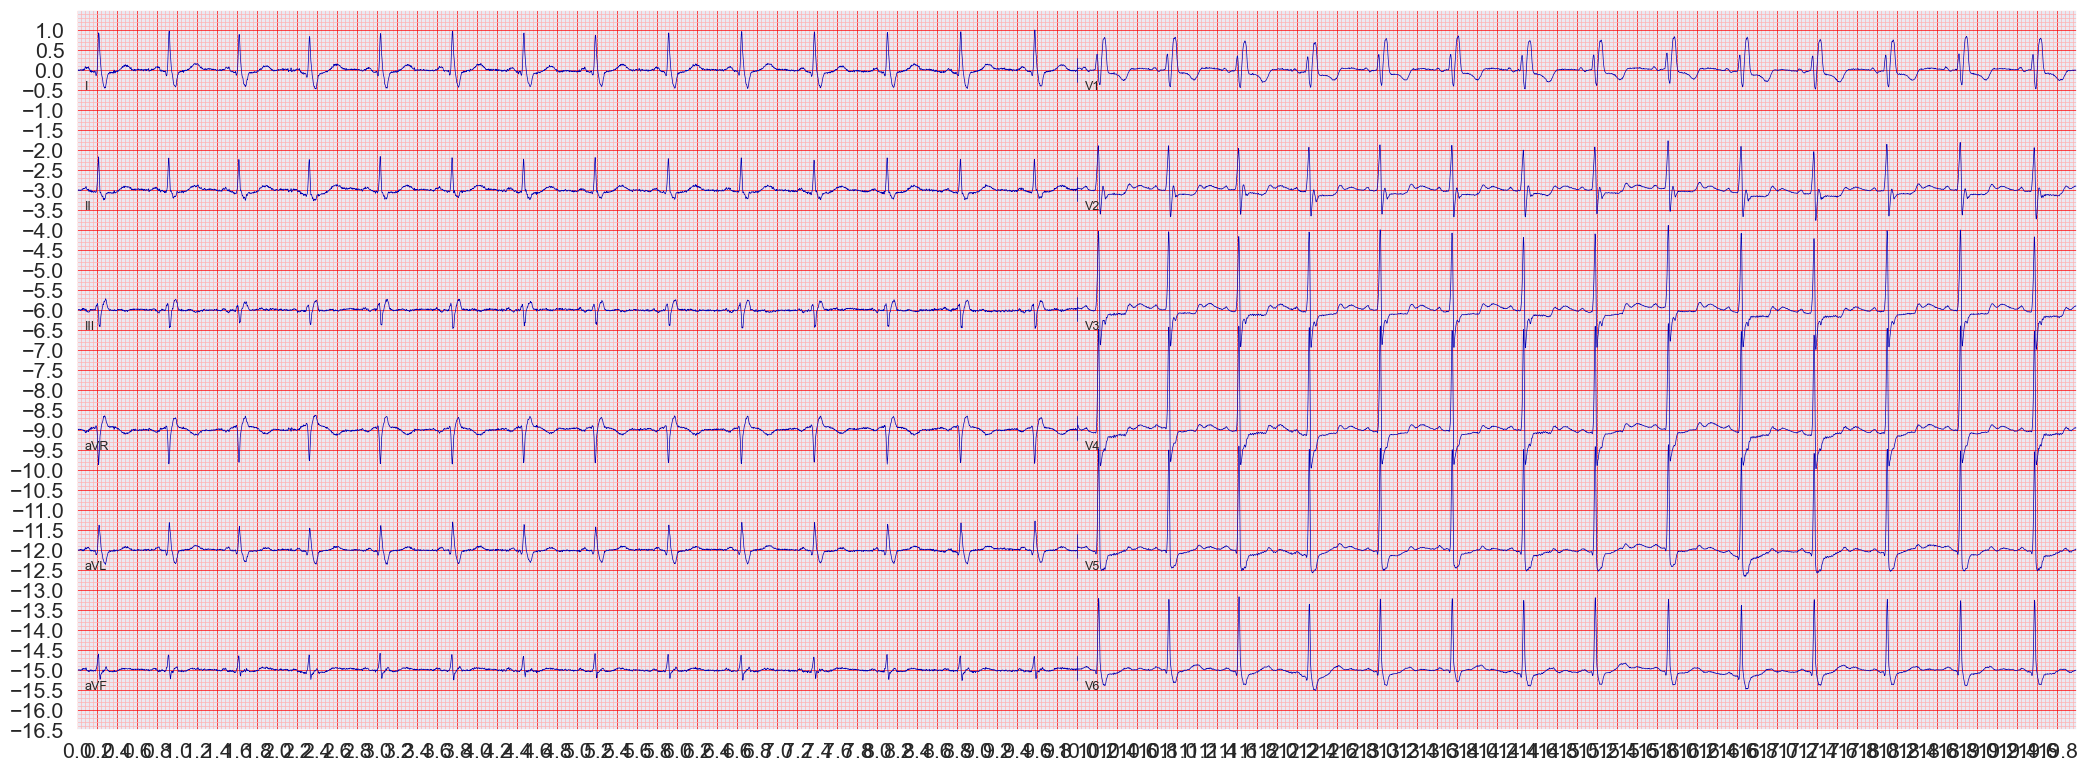

In [279]:
def plot_ecg(path):
    ecg_data = pc.load_challenge_data(path)
    ecg_plot.plot(ecg_data[0]/1000, sample_rate=500, title='')
    ecg_plot.show()

plot_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat") 

In [280]:
ecg_data = pc.load_challenge_data("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat")
ecg_data[0].shape

(12, 5000)

### Methods


#### Data
The training data in this study contains 43,101 Electrocariographic recordings from 4 different sources. 
1. Southeast University, China, including the data from the China Physiological Signal Challenge 2018 (2 datasets from this source)
2. St. Petersburg Institute of Cardiological Technics, St. Petersburg, Russia.
3. The Physikalisch Technische Bundesanstalt, Brunswick, Germany. (2 datasets from this source)
4. Georgia 12-Lead ECG Challenge Database, Emory University, Atlanta, Georgia, USA.

The data is given in the form of native Python waveform-database-format [WFDB](https://wfdb.readthedocs.io/en/latest/). The dataset contains two file types:


1.   Header files (.hea)
2.   Signal files (.mat)

We have 43,101 Signal file with a corresponding header file. Each file are named with a patient number starting with ***A0001*** and goes all the way up to ***A6877***


#### From the header file we have access to gender and age from each patient

In [281]:
SEX_RE = re.compile(r'(?i)#\s*sex\s*:\s*([A-Za-z?]+)')
AGE_RE = re.compile(r'(?i)#\s*age\s*:\s*([0-9]+|NaN|\?)')
DX_RE  = re.compile(r'(?i)#\s*dx\s*:\s*(.+)$')

def coerce_age(val):
    if val is None:
        return None
    v = val.strip()
    if v.lower() in {"nan", "?", ""}:
        return None
    try:
        return int(v)
    except ValueError:
        # sometimes age can be float-looking; try float -> int
        try:
            return int(float(v))
        except Exception:
            return None

def normalize_sex(val):
    if not val:
        return None
    v = val.strip().upper()
    # common encodings: M/F, Male/Female, U/?, etc.
    if v in {"M", "MALE"}:
        return "M"
    if v in {"F", "FEMALE"}:
        return "F"
    return None  # Unknown/other -> None (or return v if  want to keep)

def parse_header(hea_path: Path):
    sex = age = label = None
    signal_len = None
    fs = None

    with open(hea_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    if not lines:
        return sex, age, label, signal_len, fs

    # First line usually like: "<recname> <n_sig> <fs> <nsamp> <date> <time>"
    first = lines[0].strip()
    parts = first.split()
    if len(parts) >= 4:
        # parts[2] = fs, parts[3] = number of samples
        try:
            fs = int(float(parts[2]))
        except Exception:
            fs = None
        try:
            signal_len = int(parts[3])
        except Exception:
            signal_len = None

    # Now scan ALL lines for comment metadata
    for raw in lines:
        ln = raw.strip()
        if not ln.startswith("#"):
            continue

        m = SEX_RE.search(ln)
        if m and sex is None:
            sex = normalize_sex(m.group(1))

        m = AGE_RE.search(ln)
        if m and age is None:
            age = coerce_age(m.group(1))

        m = DX_RE.search(ln)
        if m and label is None:
            # Keep the raw label string; or split to list if  prefer
            label = m.group(1).strip()

    return sex, age, label, signal_len, fs

CSV_CACHE = r"notebooks\finalproject\ecg_index.csv"

def build_index(root, cache_path=CSV_CACHE):
    """
    Scan dataset and build a CSV index with ECG metadata.
    """
    rows = []
    root = Path(root)

    for mat_path in sorted(root.rglob("*.mat")):
        hea_path = mat_path.with_suffix(".hea")
        if not hea_path.exists():
            continue

        _, header_data = pc.load_challenge_data(str(mat_path))

        # mimic original parsing
        label  = header_data[15][5:-1]
        gender = header_data[14][6:-1]
        age    = header_data[13][6:-1]

        # try to grab fs and signal length from first line
        fs = siglen = duration = None
        try:
            parts = header_data[0].split()
            if len(parts) >= 4:
                fs = int(float(parts[2]))
                siglen = int(parts[3])
                duration = siglen / fs if (fs and siglen) else None
        except Exception:
            pass

        rows.append({
            "mat": str(mat_path),
            "hea": str(hea_path),
            "sex": gender,
            "age": age,
            "label": label,
            "signal_len": siglen,
            "fs": fs,
            "duration_sec": duration,
        })

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


In [282]:
REQUIRED_COLS = {"sex", "age", "label", "signal_len", "fs", "mat"}
CSV_CACHE = Path(r"notebooks\ecg_index.csv")

def _load_metadata(cache_path: Path):
    df = pd.read_csv(cache_path)
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"Cache missing required columns: {missing}")
    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )

def _auto_detect_root():
    # Try a few common places for the dataset
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "data",
        cwd / "datasets",
        cwd.parent,
        cwd.parent / "data",
    ]
    for c in candidates:
        try:
            next(c.rglob("*.mat"))
            return c
        except StopIteration:
            continue
    return None

def get_or_build_ecg_metadata(root: str | Path = None,
                                cache_path: str | Path = CSV_CACHE,
                                force_rebuild: bool = False):
    """
    Return (sex, age, label, signal_len, fs, ecg_filenames).
    If cache exists/valid, read it. Otherwise, scan and build it.
    If root is None, attempt to auto-detect a dataset root.
    """
    cache_path = Path(cache_path)
    if not force_rebuild and cache_path.exists():
        return _load_metadata(cache_path)

    if root is None:
        root = _auto_detect_root()
        if root is None:
            raise RuntimeError(
                "Could not auto-detect dataset root (no .mat files found in common locations). "
                "Pass root=... explicitly."
            )
    root = Path(root)

    # Ensure cache dir exists
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    # Build CSV via existing scanner
    df = build_index(root, cache_path=cache_path)

    # Normalize some fields
    if "age" in df.columns:
        df["age"] = df["age"].apply(coerce_age)
    if "sex" in df.columns:
        df["sex"] = df["sex"].apply(normalize_sex)
    for col in ["signal_len", "fs"]:
        if col not in df.columns:
            df[col] = None

    df.to_csv(cache_path, index=False)

    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )


In [283]:
sex, age, labels, signal_len, fs, ecg_filenames = get_or_build_ecg_metadata(cache_path=CSV_CACHE)

#### From the figure under we can se that the signals varies, but most of the signals are around 5000 samples long

In [284]:
# Load CSV
df = pd.read_csv(CSV_CACHE)

def plot_signal_lengths(df, title):
    signal_count = df["signal_len"].value_counts()

    plt.figure(figsize=(20, 10))
    plt.title(title, fontsize=36)
    sns.barplot(x = signal_count[:10].index, y = signal_count[:10].values)
    plt.xlabel("Signal length (samples)", fontsize=18)
    plt.ylabel("Count", fontsize=18)
    plt.show()

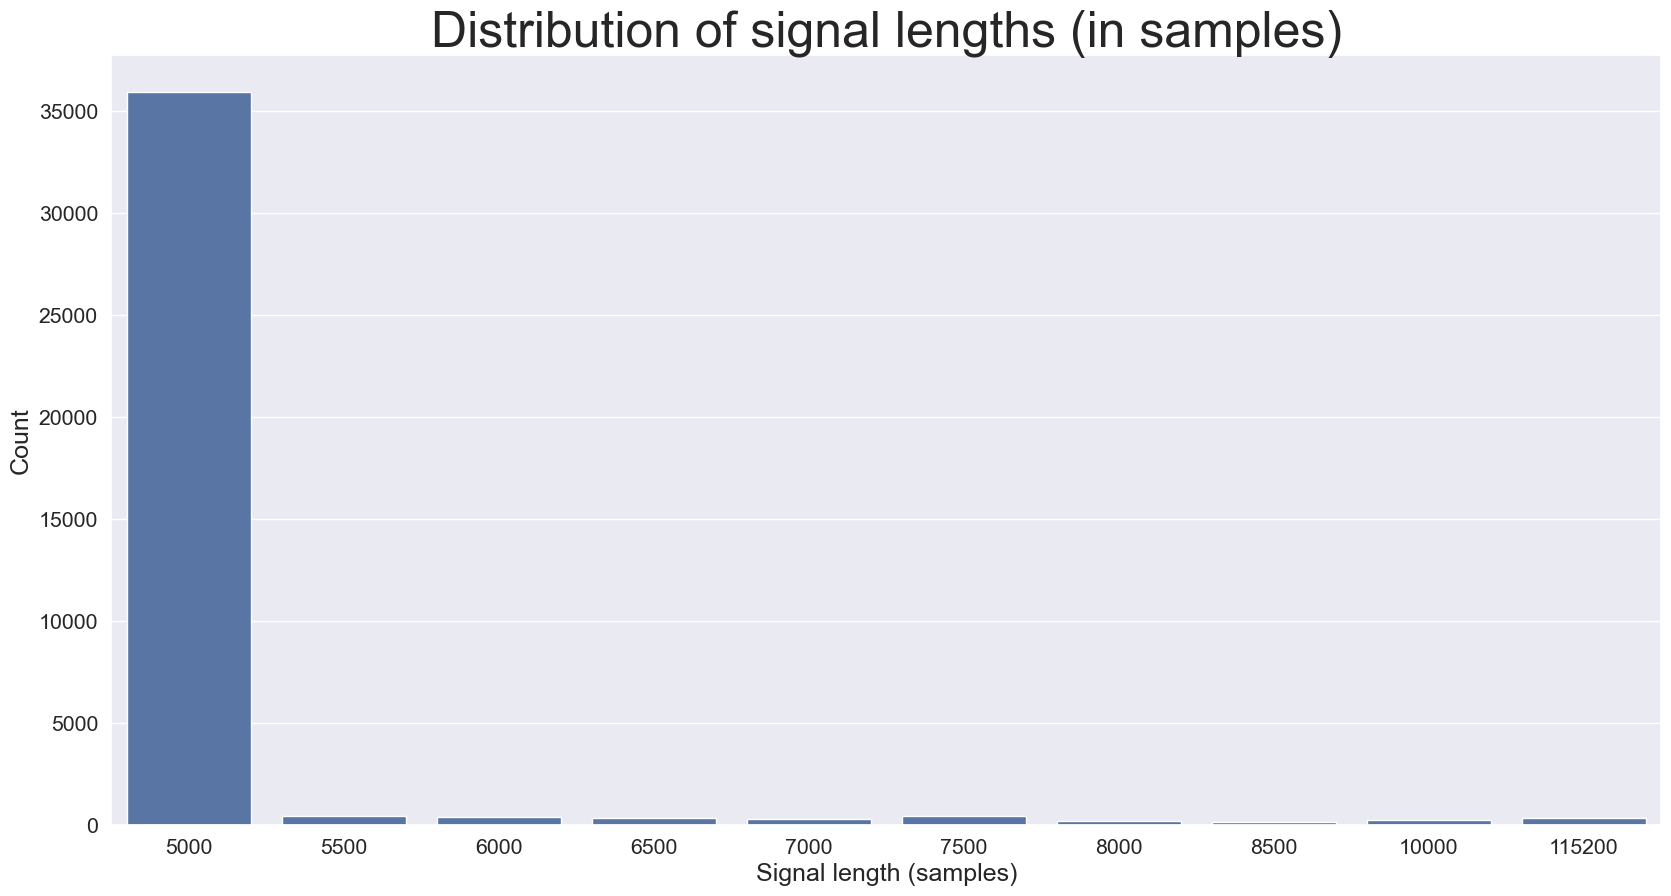

In [285]:
plot_signal_lengths(df, "Distribution of signal lengths (in samples)")

#### All diagnoses are encoded with SNOMED-CT codes. We need a CSV-file to decode them:

In [286]:
SNOMED_scored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_scored.csv", sep=";")
SNOMED_unscored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_unscored.csv", sep=";")

df_labels = pc.make_undefined_class(labels, SNOMED_unscored)

In [287]:
print(df_labels)

                                                       0
0                              undefined class,427084000
1                                        undefined class
2                        undefined class,undefined class
3                        undefined class,undefined class
4                                        undefined class
...                                                  ...
43096    undefined class,undefined class,undefined class
43097  undefined class,undefined class,427084000,unde...
43098  undefined class,undefined class,426627000,6359...
43099  undefined class,427084000,undefined class,unde...
43100  undefined class,426627000,undefined class,unde...

[43101 rows x 1 columns]


#### To be able to feed the labels to a Neural Network we need to OneHot encode the labels

In [288]:
y , snomed_classes = pc.onehot_encode(df_labels)

The classes we will look at are encoded as SNOMED CT codes:
['10370003' '111975006' '164889003' '164890007' '164909002' '164917005'
 '164934002' '164947007' '17338001' '251146004' '270492004' '284470004'
 '39732003' '426177001' '426627000' '426783006' '427084000' '427172004'
 '427393009' '445118002' '47665007' '59118001' '59931005' '63593006'
 '698252002' '713426002' '713427006' 'undefined class']
classes: 27


In [289]:
y.shape

(43101, 27)

In [290]:
snomed_abbr = []
for j in range(len(snomed_classes)):
    for i in range(len(SNOMED_scored.iloc[:,1])):
        if (str(SNOMED_scored.iloc[:,1][i]) == snomed_classes[j]):
            snomed_abbr.append(SNOMED_scored.iloc[:,2][i])
            
snomed_abbr = np.asarray(snomed_abbr)

#### The distribution of diagnoses accross the dataset
In the figure under we can see the same SNOMED CT codes decoded into human readable diagnoses on the X-axis. On the Y-axis we have the number of the given diagnoses in the dataset

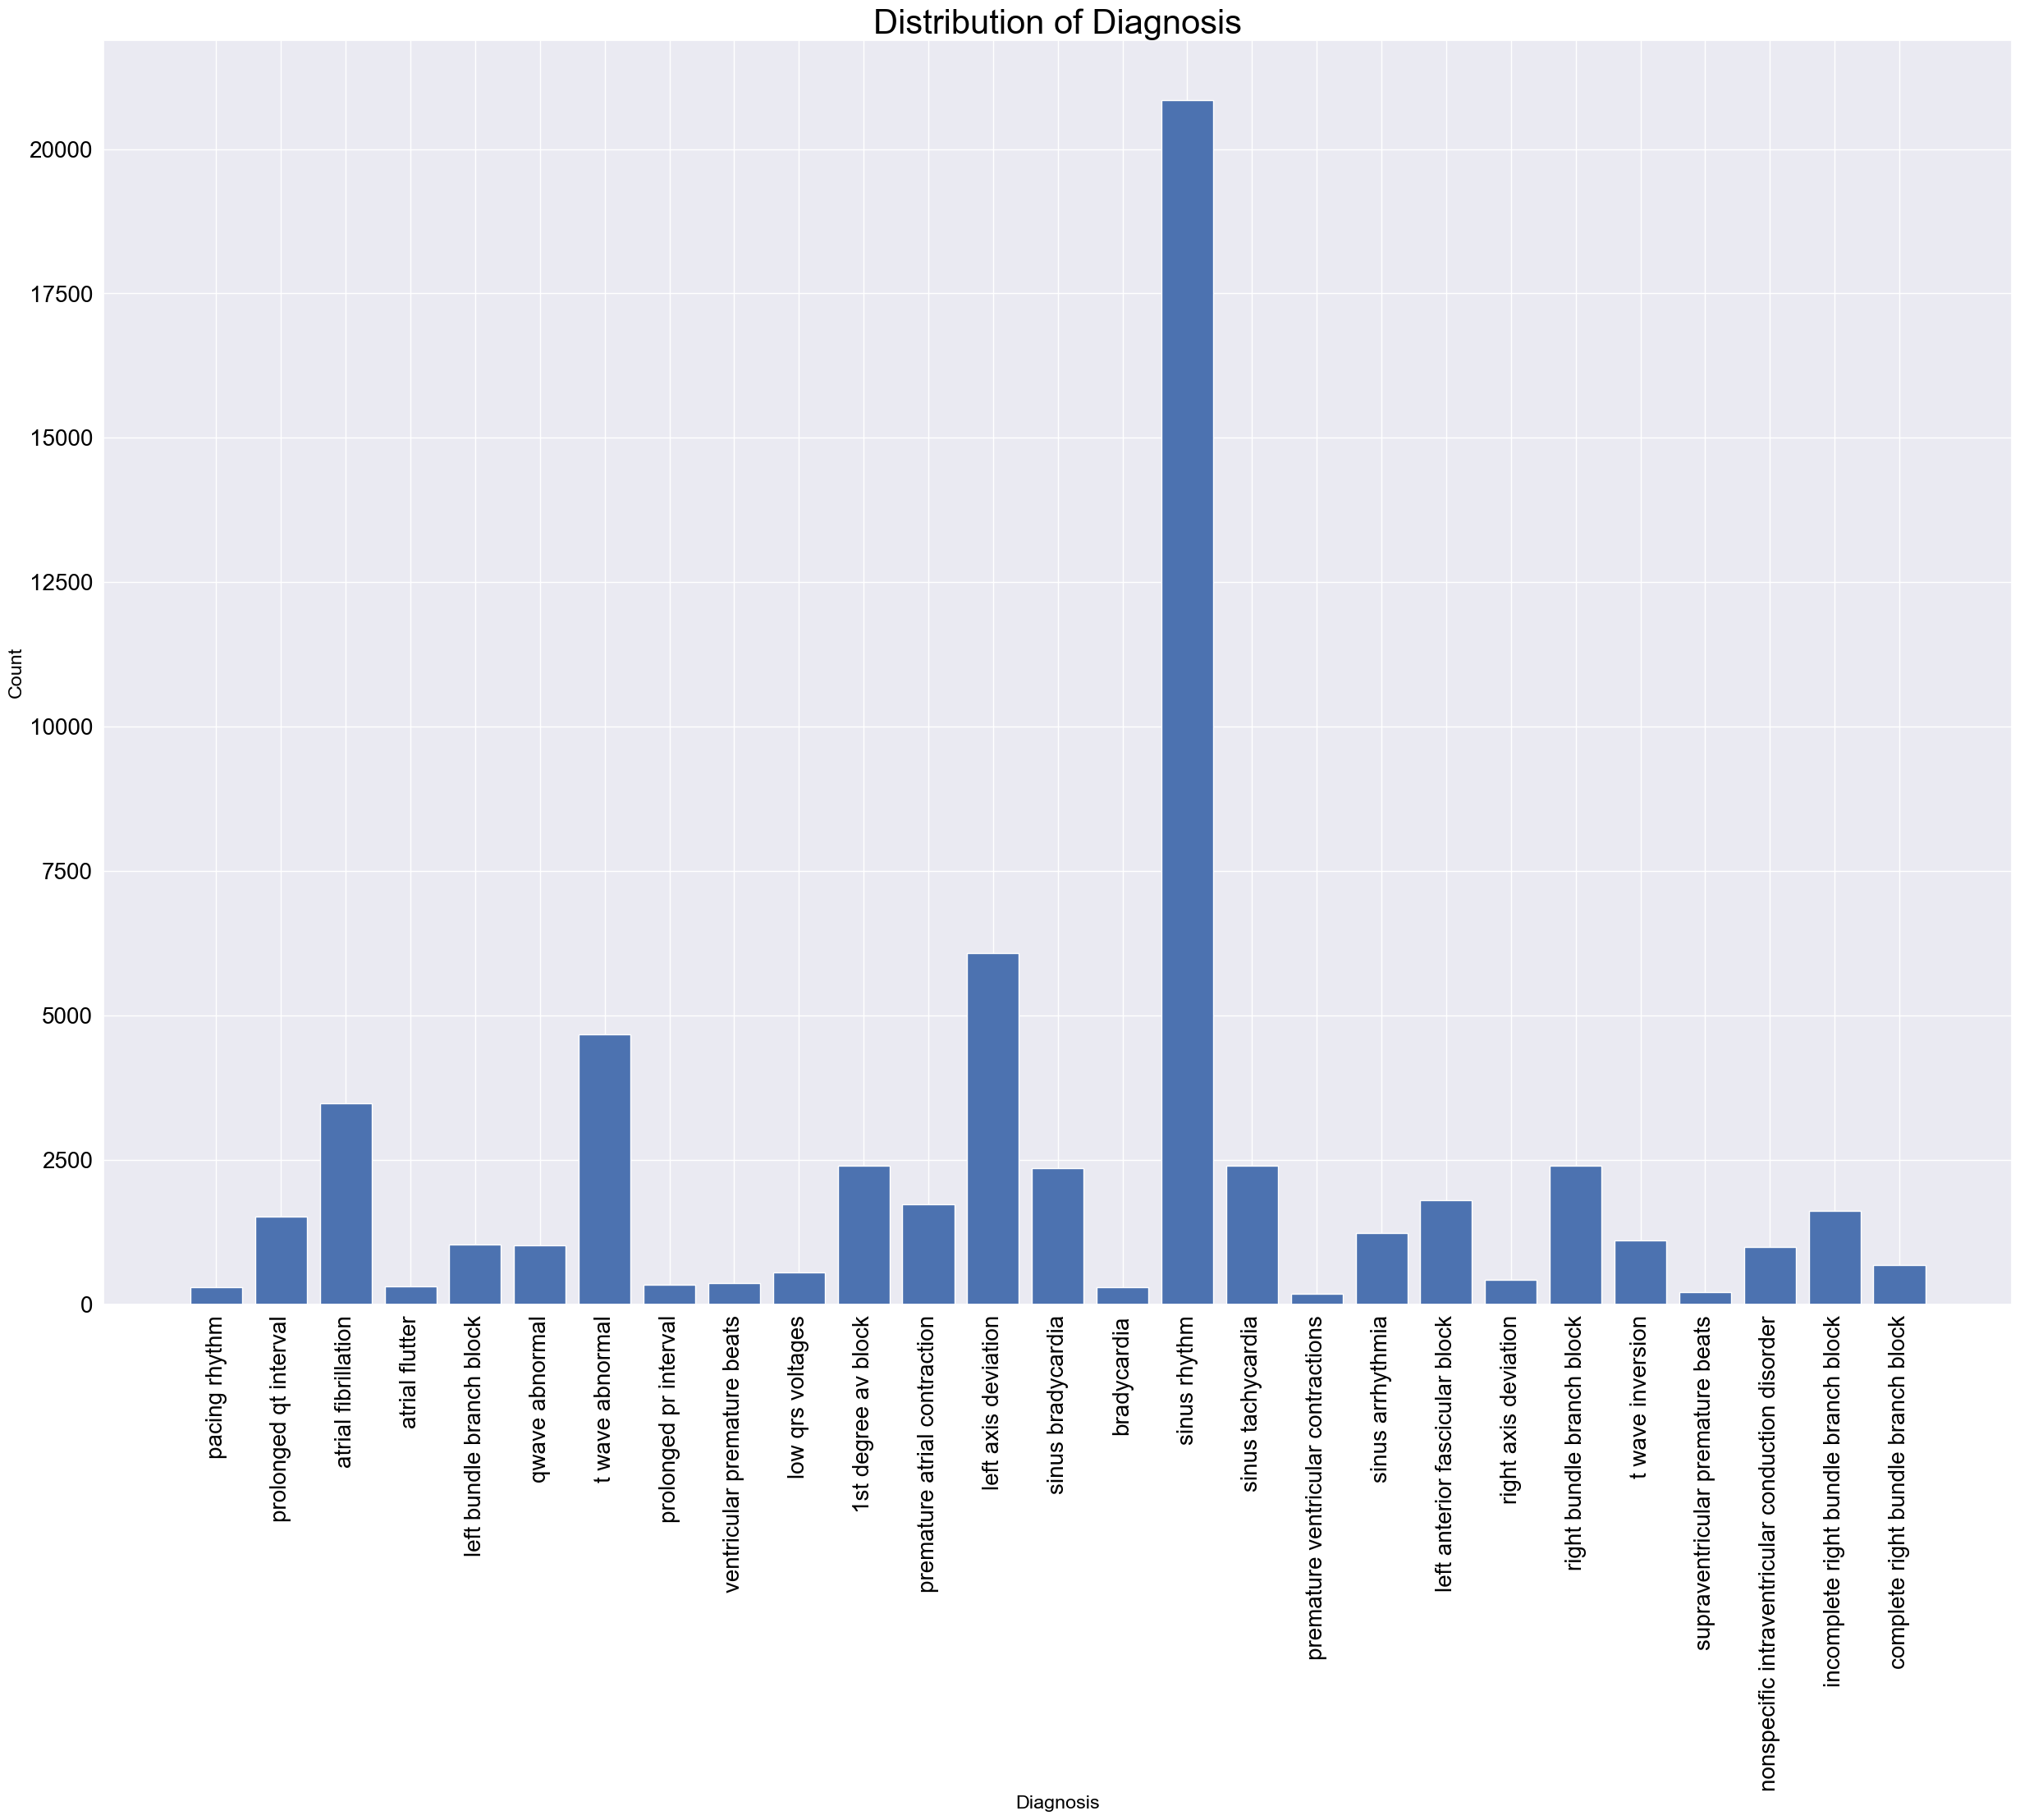

In [291]:
pc.plot_classes(snomed_classes, SNOMED_scored,y)

#### Since this is a multiclass multi-label classification there will be a lot of different combinations of the 27 diagnoses in this study

In [292]:
y_all_comb = pc.get_labels_for_all_combinations(y)
print("Total number of unique combinations of diagnosis: {}".format(len(np.unique(y_all_comb))))

Total number of unique combinations of diagnosis: 1414


#### We will split the data using a 10-fold split with Shuffle=True and random_seed = 42. 
The distribution of Training and Val data in each fold is now:
(in this study we only use the first fold for hold out validation)

In [293]:
folds = pc.split_data(labels, y_all_comb)

Training split: 38790
Validation split: 4311


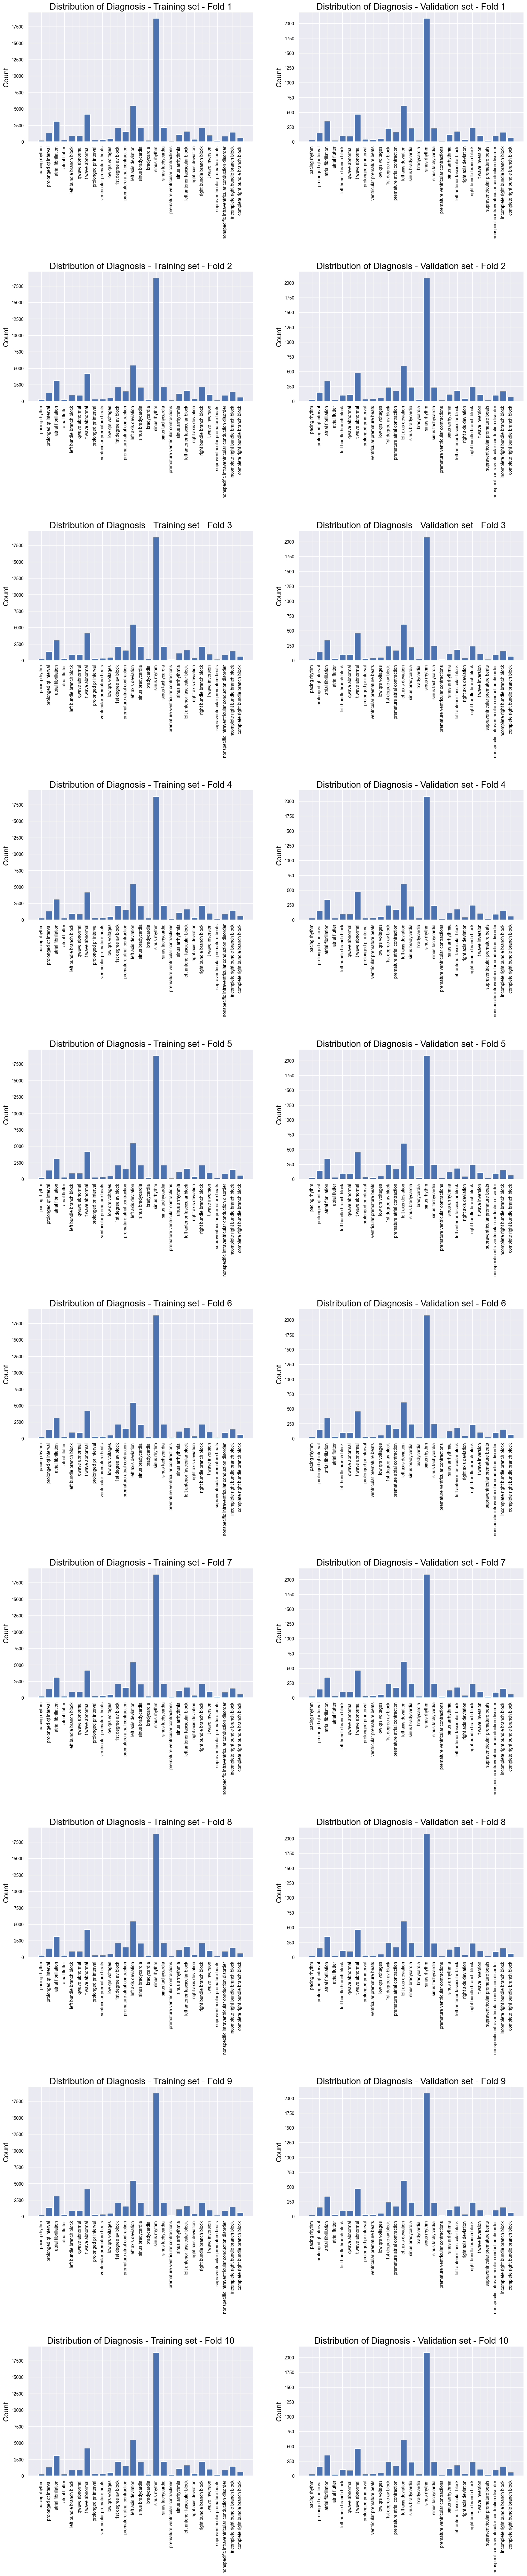

In [294]:
pc.plot_all_folds(folds,y,snomed_classes)

#### Make Batch generators
To feed the Neural Network with a dataset that is too large for our RAM set we need a batch generator to get data into the RAM in batches.
We start by making a "order array" so we can shuffle the order of the data during the training process

In [295]:
order_array = folds[0][0]

In [296]:
def shuffle_batch_generator_demo(batch_size, gen_x,gen_y, gen_z): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    batch_demo_data = np.zeros((batch_size,2))
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            batch_demo_data[i] = next(gen_z)

        X_combined = [batch_features, batch_demo_data]
        yield X_combined, batch_labels
        
def shuffle_batch_generator(batch_size, gen_x,gen_y): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            
        yield batch_features, batch_labels

def generate_y_shuffle(y_train):
    while True:
        for i in order_array:
            y_shuffled = y_train[i]
            yield y_shuffled

def generate_X_shuffle(X_train):
    while True:
        for i in order_array:
                #if filepath.endswith(".mat"):
                    data, header_data = pc.load_challenge_data(X_train[i])
                    X_train_new = pad_sequences(data, maxlen=5000, truncating='post',padding="post")
                    X_train_new = X_train_new.reshape(5000,12)
                    yield X_train_new

def generate_z_shuffle(age_train, gender_train):
    while True:
        for i in order_array:
            gen_age = age_train[i]
            gen_gender = gender_train[i]
            z_train = [gen_age , gen_gender]
            yield z_train

#### Imbalanced data
To compensate for the imbalaced data we calculate a weight for each label. The weight decides how much the Neural Network will learn from the different data labels

In [297]:
new_weights=pc.calculating_class_weights(y)

In [298]:
keys = np.arange(0,27,1)
weight_dictionary = dict(zip(keys, new_weights.T[1]))
weight_dictionary

{0: 72.0752508361204,
 1: 14.243555849306015,
 2: 6.201582733812949,
 3: 68.63216560509554,
 4: 20.701729106628243,
 5: 21.273938795656466,
 6: 4.611705542478066,
 7: 63.383823529411764,
 8: 59.04246575342466,
 9: 38.759892086330936,
 10: 9.00187969924812,
 11: 12.464141122035858,
 12: 3.5409957279000985,
 13: 9.13543874523103,
 14: 74.828125,
 15: 1.0337954523649622,
 16: 8.971898417985013,
 17: 114.63031914893617,
 18: 17.379435483870967,
 19: 11.932724252491694,
 20: 50.469555035128806,
 21: 8.971898417985013,
 22: 19.379946043165468,
 23: 100.23488372093023,
 24: 21.615346038114343,
 25: 13.37709497206704,
 26: 31.552708638360176}

#### Learning rate reduction
To controll the learning rate we use learning rate reduction and early stopping to prevent overfitting

In [299]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_AUC', factor=0.1, patience=1, verbose=1, mode='max',
    min_delta=0.0001, cooldown=0, min_lr=0
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_AUC', mode='max', verbose=1, patience=2)

#### To find the optimal threshold we will use Downhill simplex method

In [300]:
def thr_chall_metrics(thr, label, output_prob):
    return -pc.compute_challenge_metric_for_opt(label, np.array(output_prob>thr))

### Results

#### Residual Neural Network

In [301]:
model = pc.residual_network_1d()

load a pre-trained model - trained parameters (weights & biases)

In [302]:
model.load_weights("data/physionet-challenge-models/resnet_model.h5")

#### Visualizing the Model

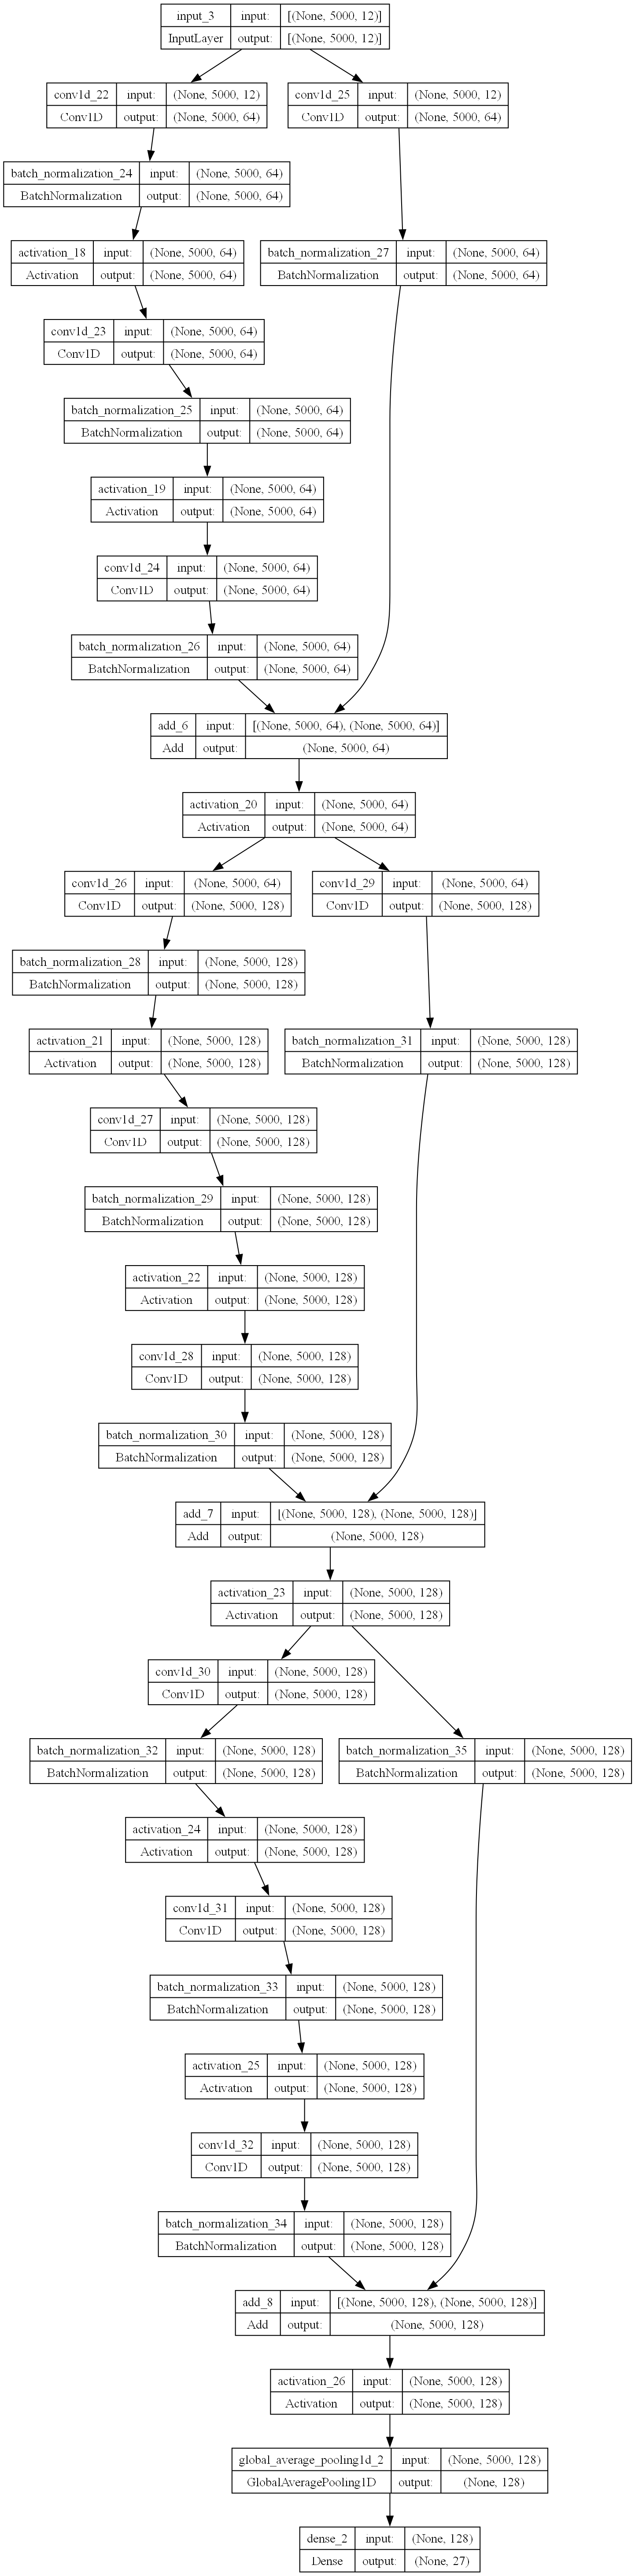

In [303]:
plot_model(
    model,
    to_file="resnet1d.png",
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",   # vertical; use "LR" for left→right
    dpi=150
)

In [304]:
ecg_filenames = np.asarray(ecg_filenames, dtype=object)
y_pred = model.predict(x = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0])

135/135 [==============================] - 92s 681ms/step


In [305]:
init_thresholds = np.arange(0, 1, 0.05)

In [306]:
all_scores = pc.iterate_threshold(y_pred, ecg_filenames, y, folds[0][1])

0.1516625863156977
0.16451787609569868
0.179296576049544
0.19244156458969178
0.20521250632536797
0.21677736341471268
0.22703882973089007
0.23903374617705025
0.2502025422659532
0.2595737464768863
0.2686674666984639
0.27500990906874334
0.280236881455952
0.2849755079498483
0.2862131171043737
0.25841620764355727
0.21307896098257953
0.10570764107659067
-0.07579223683565757
-0.3799632795479918


In [307]:
new_best_thr = optimize.fmin(thr_chall_metrics, 
                                args = (pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1], y_pred), 
                                x0 = init_thresholds[all_scores.argmax()] * np.ones(27))

Optimization terminated successfully.
         Current function value: -0.396408
         Iterations: 508
         Function evaluations: 875


In [308]:
print(pc.compute_challenge_metric_for_opt(pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1],(y_pred>new_best_thr)*1))

0.396408194454724


Make conf.matrix

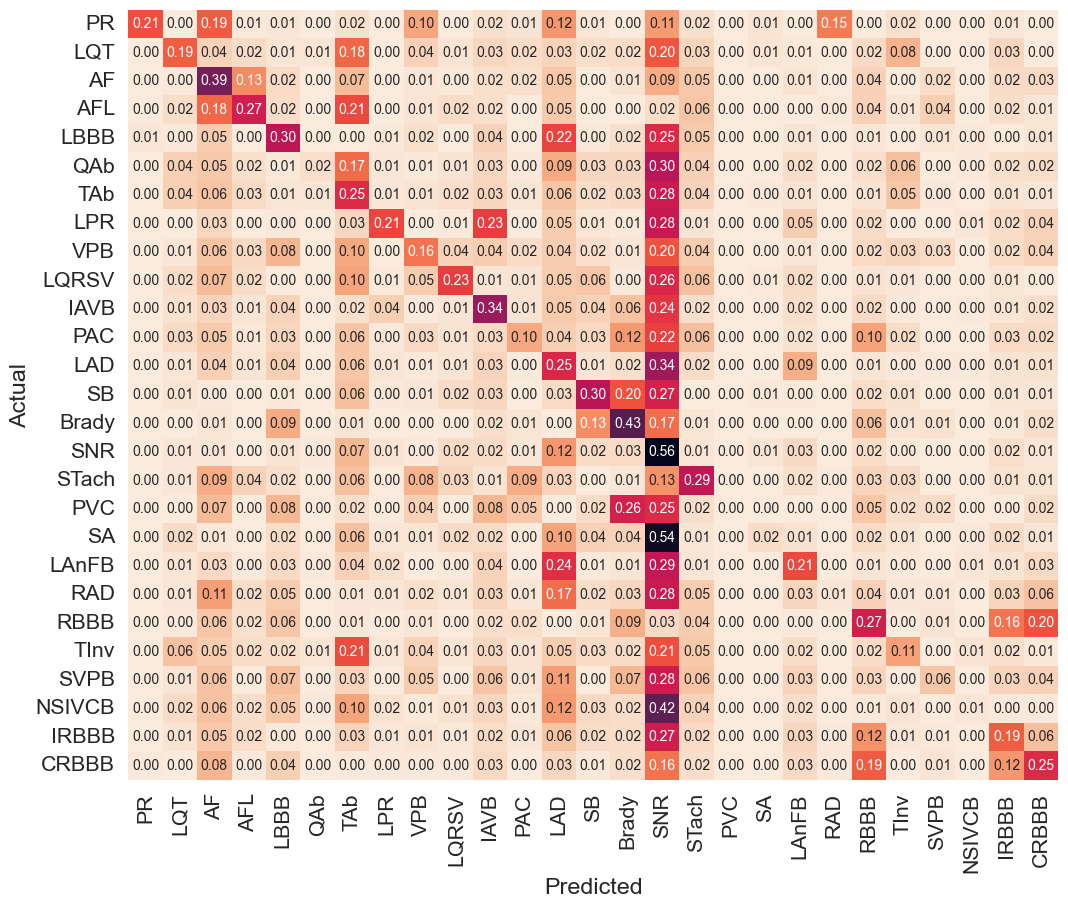

In [309]:
pc.plot_normalized_conf_matrix(y_pred, ecg_filenames, y, folds[0][1], new_best_thr, snomed_classes, snomed_abbr)
plt.savefig("confusion_matrix_resnet.png", dpi=100)

In [310]:
test_aa = pc.generate_validation_data(ecg_filenames,y,folds[0][1])[0]
print(test_aa.shape)

(4311, 5000, 12)


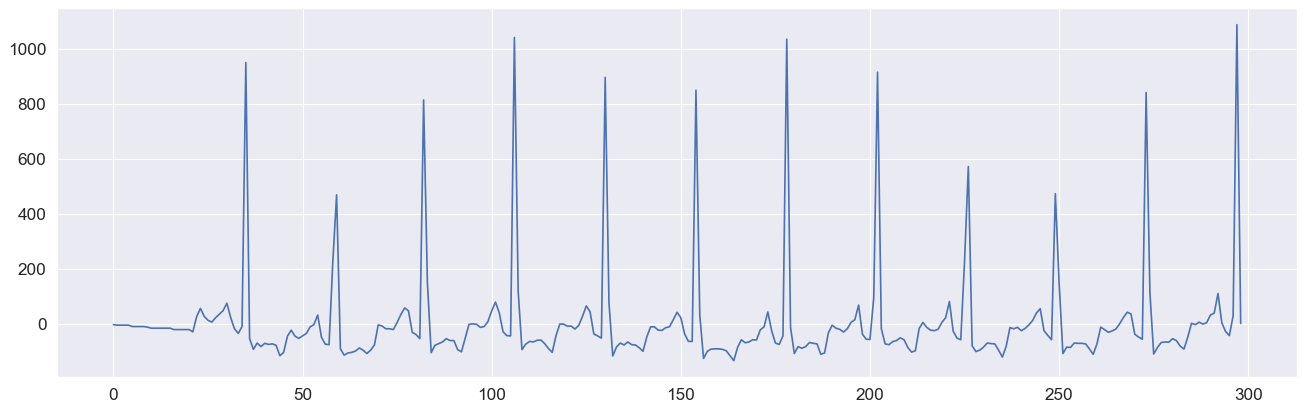

In [311]:
figure(figsize=(20, 6), dpi=80)
plt.plot(test_aa[0,1:300,0])

In [312]:
y_pred.shape

(4311, 27)

In [313]:
test_aa[:2,:,:].shape

(2, 5000, 12)

In [314]:
sample = np.array(test_aa[0:10]).copy()
sample.shape

(10, 5000, 12)

In [315]:
ecg_multilabel_eval_path = r"C:\Users\nares\Documents\cvd-early-detection-ecg-uhull\notebooks\ecg_multilabel_eval.py"
sys.path.append(os.path.dirname(ecg_multilabel_eval_path))
from ecg_multilabel_eval import compute_per_class_metrics, plot_roc_for_top_k

In [316]:
# Use your existing predictions for the validation fold:
val_idx = folds[0][1]                 # validation indices for fold 0
y_val_true = y[val_idx]               # (N_val, C), binary
y_val_prob = y_pred                   # (N_val, C) from your model.predict(...)
class_names = list(snomed_classes)    # length C

per_class = compute_per_class_metrics(y_val_true, y_val_prob, class_names)
print("micro AUROC:", per_class.attrs["micro_auroc"])
print("macro AUROC:", per_class.attrs["macro_auroc"])
per_class.sort_values("prevalence", ascending=False).head(15)

micro AUROC: 0.9120356768218301
macro AUROC: 0.8787444471389166


,class_name,prevalence,accuracy,sensitivity,specificity,auroc,auprc,threshold,tp,fp,tn,fn
15,sinus rhythm,0.484110,0.867780,0.862961,0.872302,0.934240,0.924108,0.685033,1801,284,1940,286
12,left axis deviation,0.141730,0.757133,0.808511,0.748649,0.857224,0.533486,0.507155,494,930,2770,117
6,t wave abnormal,0.108096,0.722570,0.757511,0.718336,0.804801,0.376893,0.517570,353,1083,2762,113
2,atrial fibrillation,0.082116,0.943401,0.929379,0.944655,0.977140,0.844290,0.753770,329,219,3738,25
21,right bundle branch block,0.054744,0.899095,0.932203,0.897178,0.969219,0.773309,0.745539,220,419,3656,16
13,sinus bradycardia,0.054512,0.910230,0.940426,0.908489,0.971970,0.724486,0.403590,221,373,3703,14
16,sinus tachycardia,0.054280,0.936210,0.961538,0.934756,0.979764,0.795298,0.629349,225,266,3811,9
10,1st degree av block,0.053352,0.931338,0.873913,0.934575,0.968033,0.666671,0.785306,201,267,3814,29
19,left anterior fascicular block,0.041290,0.835305,0.921348,0.831599,0.945042,0.503133,0.270798,164,696,3437,14
11,premature atrial contraction,0.039434,0.582927,0.735294,0.576672,0.688208,0.081765,0.696575,125,1753,2388,45


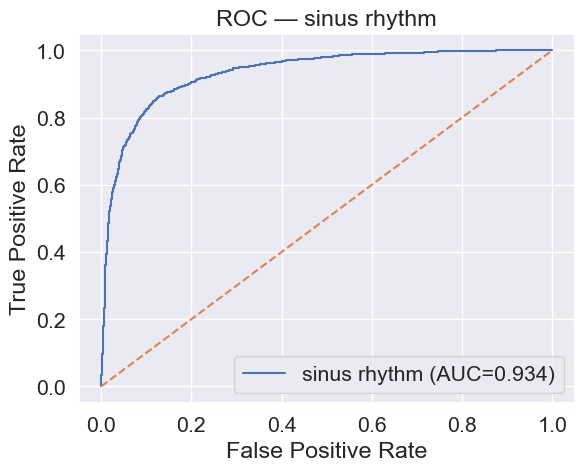

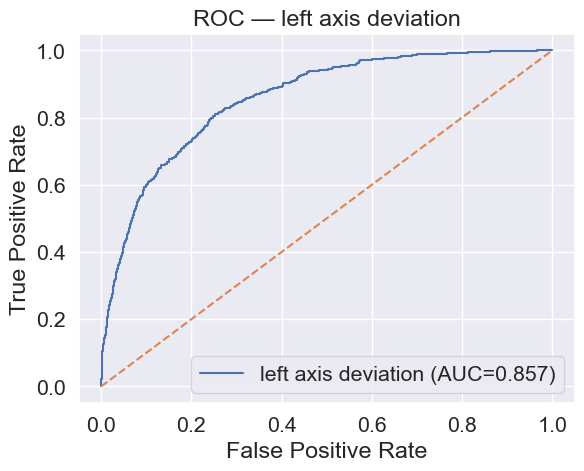

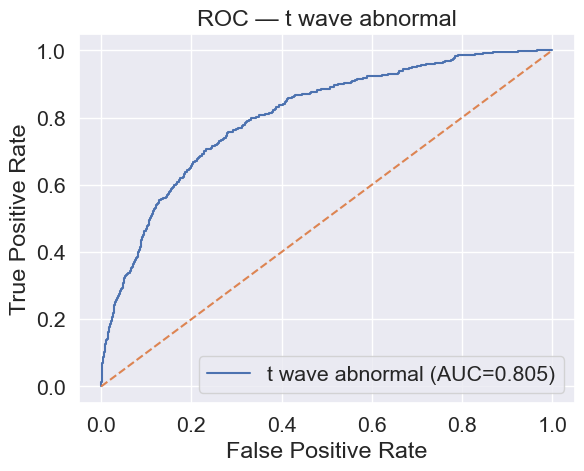

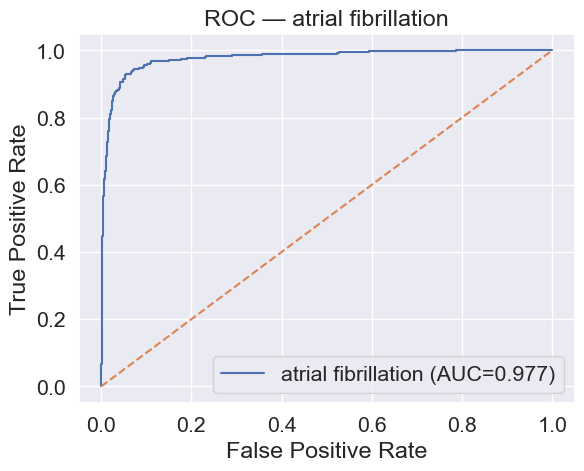

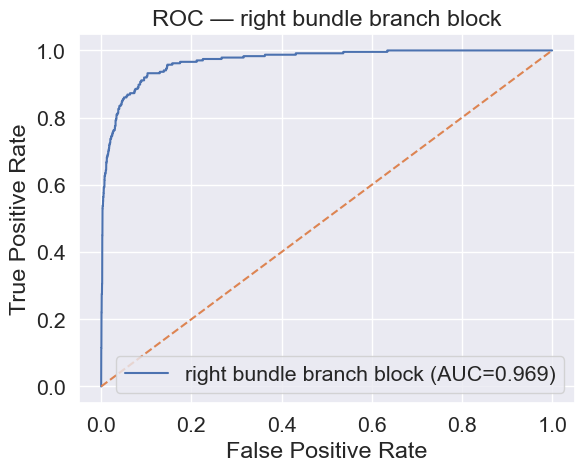

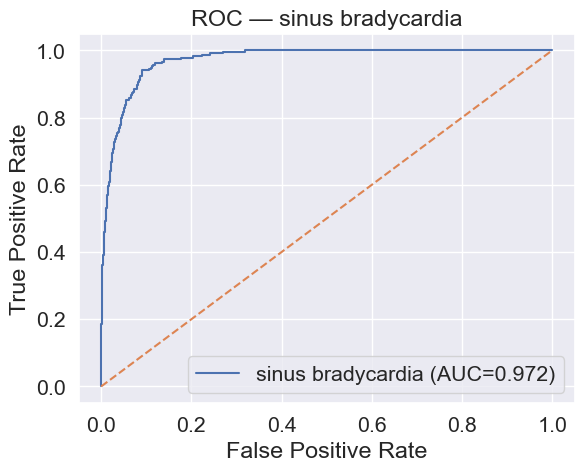

In [317]:
plot_roc_for_top_k(y_val_true, y_val_prob, class_names, k=6)

In [318]:
meta = pd.read_csv(CSV_CACHE)

# Make a per-record DF for the current validation fold:
from ecg_multilabel_eval import make_eval_dataframe_for_fold

df_val = make_eval_dataframe_for_fold(
    val_idx=val_idx,
    ecg_filenames=ecg_filenames,
    y_true=y,
    y_prob=y_pred,
    class_names=class_names,
    meta_df=meta,             # optional; merges on "filename"
    file_col=ecg_filenames      # change if your column name differs
)
df_val.head()

,filename,y_pacing rhythm,p_pacing rhythm,y_prolonged qt interval,p_prolonged qt interval,y_atrial fibrillation,p_atrial fibrillation,y_atrial flutter,p_atrial flutter,y_left bundle branch block,...,y_complete right bundle branch block,p_complete right bundle branch block,mat,hea,sex,age,label,signal_len,fs,duration_sec
0,C:\Users\nares\Documents\cvd-early-detection-e...,0,0.010392,0,0.349663,0,0.264930,0,0.111756,0,...,0,0.047475,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,F,53.0,"428750005,427084000",20846,500,41.692
1,C:\Users\nares\Documents\cvd-early-detection-e...,0,0.003367,0,0.066143,0,0.285696,0,0.112310,0,...,0,0.328979,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,M,57.0,"164867002,426627000",5000,500,10.000
2,C:\Users\nares\Documents\cvd-early-detection-e...,0,0.006393,0,0.550632,0,0.058351,0,0.141291,0,...,0,0.102396,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,F,63.0,164867002,28376,500,56.752
3,C:\Users\nares\Documents\cvd-early-detection-e...,0,0.020433,0,0.041240,0,0.157413,0,0.037543,0,...,0,0.184865,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,M,68.0,"284470004,428750005",17000,500,34.000
4,C:\Users\nares\Documents\cvd-early-detection-e...,0,0.038196,0,0.018313,0,0.478870,0,0.168137,0,...,0,0.067899,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,M,87.0,"27885002,164865005",11500,500,23.000


In [319]:
from ecg_multilabel_eval import subgroup_table_binary

target = "atrial fibrillation"

df_val["age_band"] = pd.cut(df_val["age"], bins=[0,40,60,80,200], labels=["<=40","41-60","61-80",">80"])
df_val["len_band"] = pd.qcut(df_val["signal_len"], q=4, duplicates="drop")

tab_sex = subgroup_table_binary(df_val, label_col=f"y_{target}", prob_col=f"p_{target}", group_col="sex")
tab_age = subgroup_table_binary(df_val, label_col=f"y_{target}", prob_col=f"p_{target}", group_col="age_band")
tab_len = subgroup_table_binary(df_val, label_col=f"y_{target}", prob_col=f"p_{target}", group_col="len_band")
tab_fs  = subgroup_table_binary(df_val, label_col=f"y_{target}", prob_col=f"p_{target}", group_col="fs")

In [320]:
tab_len

,len_band,n,prevalence,Accuracy,Sensitivity,Specificity,AUROC,AUPRC,TP,FP,TN,FN
0,"(2499.999, 5000.0]",3606,0.075707,0.947310,0.919414,0.949595,0.975501,0.826092,251,168,3165,22
1,"(5000.0, 462600.0]",705,0.114894,0.923404,0.962963,0.918269,0.985656,0.906921,78,51,573,3


In [321]:
tab_age

,age_band,n,prevalence,Accuracy,Sensitivity,Specificity,AUROC,AUPRC,TP,FP,TN,FN
2,61-80,1947,0.106317,0.932203,0.932367,0.932184,0.976304,0.890988,193,118,1622,14
1,41-60,1306,0.035988,0.964778,0.872340,0.968229,0.973535,0.822201,41,40,1219,6
0,<=40,583,0.008576,0.960549,1.000000,0.960208,0.998616,0.810000,5,23,555,0
3,>80,457,0.199125,0.905908,0.945055,0.896175,0.958806,0.782262,86,38,328,5


In [322]:
tab_len

,len_band,n,prevalence,Accuracy,Sensitivity,Specificity,AUROC,AUPRC,TP,FP,TN,FN
0,"(2499.999, 5000.0]",3606,0.075707,0.947310,0.919414,0.949595,0.975501,0.826092,251,168,3165,22
1,"(5000.0, 462600.0]",705,0.114894,0.923404,0.962963,0.918269,0.985656,0.906921,78,51,573,3


In [323]:
tab_fs

,fs,n,prevalence,Accuracy,Sensitivity,Specificity,AUROC,AUPRC,TP,FP,TN,FN
0,500,4252,0.08302,0.943791,0.932011,0.944858,0.977555,0.847067,329,215,3684,24
1,1000,48,0.00000,1.000000,0.000000,1.000000,NaN,0.000000,0,0,48,0


In [324]:
def youden_threshold(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    if y_true.max() == y_true.min():
        return 0.5
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def plotly_confusion_matrix(cm, title="Confusion Matrix", normalize=None):
    """
    cm: 2x2 ndarray (TN FP / FN TP with labels=[0,1])
    normalize: None | 'true' (row-wise) | 'pred' (col-wise) | 'all'
    """
    cm = np.asarray(cm, dtype=float)

    def pct_text(arr):
        return np.char.add(np.round(arr * 100.0, 1).astype(str), '%')

    # Normalize safely (avoid NaNs on zero-division)
    if normalize == 'true':
        denom = cm.sum(axis=1, keepdims=True)
        z = np.divide(cm, denom, out=np.zeros_like(cm), where=denom != 0)
        ztext = pct_text(z)
    elif normalize == 'pred':
        denom = cm.sum(axis=0, keepdims=True)
        z = np.divide(cm, denom, out=np.zeros_like(cm), where=denom != 0)
        ztext = pct_text(z)
    elif normalize == 'all':
        denom = cm.sum()
        z = cm / denom if denom != 0 else np.zeros_like(cm)
        ztext = pct_text(z)
    else:
        z = cm
        ztext = cm.astype(int).astype(str)

    fig = go.Figure(
        data=go.Heatmap(
            z=z,
            x=["Pred 0", "Pred 1"],
            y=["True 0", "True 1"],
            text=ztext,
            texttemplate="%{text}",
            hovertemplate="True %{y} • %{x}<br>Value: %{z:.3f}<extra></extra>",
            colorscale="Blues",
            showscale=True
        )
    )
    fig.update_layout(
        title=title,
        xaxis_title="Predicted label",
        yaxis_title="True label",
        yaxis_autorange="reversed",  # TN at top-left
        template="plotly_white",
        width=500, height=450,
        margin=dict(l=60, r=20, t=60, b=50)
    )
    return fig



In [325]:
target = "atrial fibrillation"  # or your exact suffix; use underscores only if your columns have underscores

y_true_all = df_val[f"y_{target}"].astype(int).values
y_prob_all = df_val[f"p_{target}"].astype(float).values

thr = youden_threshold(y_true_all, y_prob_all)  # or set your own clinical threshold
y_pred_all = (y_prob_all >= thr).astype(int)

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0,1])
fig = plotly_confusion_matrix(cm, title=f"Confusion Matrix — {target} (thr={thr:.3f})", normalize=None)  # or 'true' / 'pred' / 'all'
fig.show()


In [326]:
def plot_group_conf_mats(df, label_col, prob_col, group_col, threshold=None, min_group_n=1, normalize=None):
    y_true_all = df[label_col].astype(int).values
    y_prob_all = df[prob_col].astype(float).values
    if threshold is None:
        threshold = youden_threshold(y_true_all, y_prob_all)

    figs = {}
    for g, gdf in df.groupby(group_col):
        if len(gdf) < min_group_n:
            continue
        yt = gdf[label_col].astype(int).values
        yp = (gdf[prob_col].astype(float).values >= threshold).astype(int)
        cm = confusion_matrix(yt, yp, labels=[0,1])
        title = f"{group_col} = {g} (n={len(gdf)}, thr={threshold:.3f})"
        figs[g] = plotly_confusion_matrix(cm, title=title, normalize=normalize)
    return figs  # dict: group -> figure

# Age band
figs_age = plot_group_conf_mats(
    df_val, label_col=f"y_{target}", prob_col=f"p_{target}",
    group_col="age_band", threshold=None, min_group_n=1, normalize='true'
)
for g, fig in figs_age.items():
    fig.show()

# Sex
figs_sex = plot_group_conf_mats(
    df_val, label_col=f"y_{target}", prob_col=f"p_{target}",
    group_col="sex", threshold=None, min_group_n=1, normalize='true'
)
for g, fig in figs_sex.items():
    fig.show()


### Fuse (LIME + TIMESHAP) Explanations - Local

The following code explains the script that aligns TimeSHAP and LIME on the same, grouped time window of an ECG, to compare/fuse them fairly and plot on the raw signal.

**The script does the following:**

- Pick one ECG (ecg_sample) and take the last SECS seconds as the tail to explain.
- Group (downsample) the tail in time by averaging GROUP consecutive samples → a shorter sequence K' = ceil(K/GROUP) that’s cheaper for both explainers.
- Run TimeSHAP on the grouped tail with the same target class and baseline choice used for LIME.
- Run LIME on the same grouped tail, using the same target class and removal policy as TimeSHAP’s baseline.

**Convert both outputs to:**
- Per-time series at grouped resolution (K')
- Upsampled back to full resolution (K) for overlays on raw ECG
- Provide diagnostics (correlations) and return everything in an aligned dict for plotting.

**Key configuration**

- `FS`: original sampling rate (Hz)
- `SECS`: tail length in seconds; K = int(SECS*FS)
- `GROUP`: temporal mean-pooling factor (e.g., 10, 20). Larger → fewer steps → faster
- `UPSAMPLE_MODE`: how to map grouped outputs back to full length
    - "repeat" (fast, blocky)
    - "interp" (linear interpolation)
- `TARGET_IDX`: class index want to explain (same for TS and LIME)
- `BASELINE_MODE`: must match LIME’s removal
    - "mean": use per-feature mean across time as baseline/removal
    - "zero": use zeros baseline/removal
- `FAST`: toggles lighter/faster settings for TS & LIME sampling

Why grouping? It reduces the sequence length TimeSHAP/LIME must handle. We typically get similar patterns at a fraction of the cost.

## LIME

### Explainer

In [327]:
# ============================================
# Two/N-pass LIME with stitching + ResNet shim
# ============================================
import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# --- lead lists (match your plotter) ---
DEFAULT_LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
LIMB   = ["I","II","III","aVR","aVL","aVF"]
VLEADS = ["V1","V2","V3","V4","V5","V6"]

def _basename(p): return os.path.basename(str(p))

def _to_Tx12_strict(x2d: np.ndarray) -> np.ndarray:
    x2d = np.asarray(x2d)
    if x2d.ndim != 2 or 12 not in x2d.shape:
        raise ValueError(f"Need (T,12) or (12,T); got {x2d.shape}")
    return x2d if x2d.shape[1] == 12 else x2d.T

def _infer_fs_from_header(header_lines, default=500):
    if not header_lines: return default
    m = re.search(r'(\d+)\s*Hz', header_lines[0])
    if m: return int(m.group(1))
    toks = header_lines[0].strip().split()
    if len(toks) >= 3 and re.fullmatch(r'\d+(\.\d+)?', toks[2]):
        return int(float(toks[2]))
    return default

def _group_meanpool(x: np.ndarray, group: int):
    """Non-overlapping mean pool over time axis (T,12) -> (ceil(T/g),12)."""
    T, F = x.shape
    Kp = int(np.ceil(T / group))
    out = np.zeros((Kp, F), dtype=np.float32)
    for i in range(Kp):
        s, e = i*group, min((i+1)*group, T)
        out[i] = x[s:e].mean(axis=0)
    return out, Kp

def _upsample_to_len_T(x_g: np.ndarray, T_out: int):
    """Linear upsample each lead of (Kp,12) to (T_out,12)."""
    Kp, F = x_g.shape
    if Kp == T_out:
        return x_g.astype(np.float32)
    # centers for source/target
    xs = (np.arange(Kp) + 0.5) / Kp
    xt = (np.arange(T_out) + 0.5) / T_out
    Y = np.empty((T_out, F), dtype=np.float32)
    for j in range(F):
        Y[:, j] = np.interp(xt, xs, x_g[:, j])
    return Y

def make_resnet_predictor(model, T_target=5000):
    """
    Wrap your fixed-length ResNet so LIME can call it with (B, Kp, 12).
    We upsample each (Kp,12) to (T_target,12) before prediction.
    """
    def _predict(batch_ntf: np.ndarray):
        batch_ntf = np.asarray(batch_ntf, dtype=np.float32)   # (B,Kp,12)
        B, Kp, F = batch_ntf.shape
        up = np.empty((B, T_target, F), dtype=np.float32)
        for b in range(B):
            up[b] = _upsample_to_len_T(batch_ntf[b], T_target)
        # Use model directly (fast path without .predict overhead if you like)
        return np.asarray(model(up, training=False))
    return _predict

def _lime_per_lead_series(res_lime: dict, lead_names):
    """pd.Series positive per-lead scores."""
    import pandas as pd
    F = len(lead_names)
    s = pd.Series(0.0, index=lead_names, dtype=float)
    if res_lime is None: return s
    if "feature_importance" not in res_lime: return s
    imp = np.asarray(res_lime["feature_importance"], float).ravel()
    names = res_lime.get("feature_names")
    lead_map = {L: 0.0 for L in lead_names}
    if names is None:
        for i, v in enumerate(imp[:F]):
            lead_map[lead_names[i]] += float(max(v, 0.0))
    else:
        for x, v in zip(names, imp):
            key = None
            try:
                xi = int(x)
                if   0 <= xi <  F: key = lead_names[xi]
                elif 1 <= xi <= F: key = lead_names[xi-1]
            except Exception:
                sx = str(x).strip()
                if sx in lead_names: key = sx
            if key is not None:
                lead_map[key] += float(max(v, 0.0))
    for L in lead_names:
        s[L] = lead_map[L]
    tot = float(s.sum())
    return (s / tot) if tot > 0 else s

def _topk_spans_per_lead_from_cell(res_lime: dict, event_slices: np.ndarray,
                                   lead_names, k=6, widen=0, merge_gap=0):
    """
    Use LIME cell_importance [E,F] to pick top-k events per lead.
    Return: dict lead -> list[(e_start_bin, e_end_bin, weight)]
    """
    spans = {L: [] for L in lead_names}
    if res_lime is None: return spans
    cell = np.asarray(res_lime.get("cell_importance"))
    if cell.ndim != 2: return spans
    E, F = cell.shape
    slices = np.asarray(event_slices, int)  # [E,2] on grouped timeline
    for j, L in enumerate(lead_names):
        col = np.abs(cell[:, j])
        if col.sum() == 0: 
            continue
        idx = np.argsort(col)[::-1][:k]
        # collect + optional widen + merge (in bin space)
        segs = []
        for e in idx:
            s, e2 = int(slices[e, 0]), int(slices[e, 1])
            s = max(0, s - widen); e2 = min(E, e2 + widen)
            if e2 > s:
                segs.append((s, e2, float(col[e])))
        # merge nearby segments
        if merge_gap > 0 and segs:
            segs = sorted(segs, key=lambda z: z[0])
            merged = [segs[0]]
            for (s,e2,w) in segs[1:]:
                ps,pe,pw = merged[-1]
                if s <= pe + merge_gap:
                    merged[-1] = (ps, max(pe, e2), pw + w)
                else:
                    merged.append((s,e2,w))
            segs = merged
        spans[L] = segs
    return spans

def _bins_to_seconds(spans_bins, step_sec, offset_sec=0.0):
    """Convert [(s_bin,e_bin,w), ...] -> [(s_sec,e_sec,w), ...] with offset."""
    out = []
    for (s, e, w) in spans_bins:
        ss = offset_sec + s * step_sec
        ee = offset_sec + e * step_sec
        if ee > ss:
            out.append((ss, ee, float(w)))
    return out

def run_lime_only_top5(
    csv_path: str,
    row_idx: int,
    lead_names=DEFAULT_LEADS,
    page_seconds: float = 20.0,
    group: int = 25,                # ~50 ms at 500 Hz
    n_events: int = 250,
    n_feat_masks: int = 256,
    n_event_masks: int = 256,
    batch_size: int = 1024,
    topk_leads: int = 5,
    topk_events_per_lead: int = 6,
    widen_bins: int = 1,
    merge_gap_bins: int = 1,
    seed: int = 123
):
    """
    Split the page into 10-s columns, run LIME per column, then stitch
    per-lead spans onto the page timeline. Works with your fixed-length
    ResNet by upsampling grouped inputs to (5000,12).
    Returns a payload compatible with your column-aware plotter.
    """
    import random, tensorflow as tf
    def _set_seeds(s):
        np.random.seed(s); random.seed(s)
        try: tf.random.set_seed(s)
        except Exception: pass

    # 0) locate record + load
    df = pd.read_csv(csv_path)
    fn_base = _basename(df.iloc[row_idx]["mat"])
    basenames = np.array([_basename(f) for f in ecg_filenames], dtype=object)
    loc = np.where(basenames == fn_base)[0]
    if len(loc) == 0:
        raise ValueError(f"{fn_base} not in ecg_filenames")
    i = int(loc[0]); mat_path = ecg_filenames[i]

    data_12xT, header = pc.load_challenge_data(mat_path)
    fs_hdr = _infer_fs_from_header(header, default=500)

    # 1) model input + target class (keep your original decision)
    X_single = pc.generate_validation_data(ecg_filenames, y, np.array([i]))[0]
    X_TF = _to_Tx12_strict(X_single[0])                   # (T_in, 12) e.g. (5000,12)
    preds = model.predict(X_single, verbose=0)
    target_idx = int(np.argmax(np.ravel(preds)))
    target_prob = float(np.ravel(preds)[target_idx])

    if "snomed_classes" in globals():
        classes = list(map(str, globals()["snomed_classes"]))
        target_label = classes[target_idx] if 0 <= target_idx < len(classes) else f"class_{target_idx}"
    else:
        target_label = f"class_{target_idx}"

    # 2) take last `page_seconds` from the raw record for alignment with ecg_plot
    FS_eff = int(globals().get("FS", fs_hdr))             # prefer your pipeline FS
    Kwant  = int(round(page_seconds * FS_eff))
    raw_T  = data_12xT.shape[1]
    K_use  = min(Kwant, raw_T)
    page   = data_12xT[:, -K_use:].T                      # (K_use,12) in raw microvolts
    page_sec_eff = K_use / FS_eff

    # 3) split page into ~10-s columns
    n_cols = max(1, int(round(page_sec_eff / 10.0)))      # 20s→2, 30s→3 (if ever)
    col_sec = page_sec_eff / n_cols
    # predictor shim for your ResNet
    resnet_predict = make_resnet_predictor(model, T_target=X_TF.shape[0])

    # accumulators
    perlead_spans_all = {L: [] for L in lead_names}
    perlead_score = {L: 0.0 for L in lead_names}

    # 4) run LIME per column and stitch
    for col in range(n_cols):
        _set_seeds(seed + col)
        t0 = int(round(col * col_sec * FS_eff))
        t1 = int(round(min((col+1) * col_sec * FS_eff, K_use)))
        half = page[t0:t1, :]                              # (Kh,12) raw page segment
        if half.shape[0] < 2: 
            continue

        # group -> Kp x 12
        half_g, Kp = _group_meanpool(half, group)
        step_sec = (half.shape[0] / FS_eff) / max(Kp, 1)

        # LIME on grouped half (events on grouped bins)
        res_lime = lime_local(
            model_predict=lambda xx: resnet_predict(xx),   # upsampled to model length
            x=half_g,
            class_index=target_idx,
            n_events=min(n_events, Kp),
            n_feature_masks=n_feat_masks,
            n_event_masks=n_event_masks,
            batch_size=batch_size,
            removal="mean",
            event_mode="fixed"
        )

        event_slices = np.asarray(res_lime["event_slices"], int)  # [E,2]
        # pick top-k events per lead via cell_importance
        spans_bins = _topk_spans_per_lead_from_cell(
            res_lime, event_slices, lead_names,
            k=topk_events_per_lead, widen=widen_bins, merge_gap=merge_gap_bins
        )
        # convert to seconds on column timeline, then offset by column start
        offset_sec = col * col_sec
        spans_sec = {L: _bins_to_seconds(spans_bins[L], step_sec, offset_sec)
                     for L in lead_names}

        # accumulate
        for L in lead_names:
            perlead_spans_all[L].extend(spans_sec[L])

        # accumulate per-lead score (sum of weights)
        lead_series = _lime_per_lead_series(res_lime, lead_names)
        for L in lead_names:
            perlead_score[L] += float(lead_series.get(L, 0.0))

    # 5) choose global top-k leads across the stitched page
    import heapq
    top_leads = [L for (L, s) in sorted(perlead_score.items(), key=lambda kv: kv[1], reverse=True)[:topk_leads]]

    # 6) payload
    return {
        "file": fn_base,
        "mat_path": mat_path,
        "FS": FS_eff,
        "page_seconds": float(page_sec_eff),    # effective
        "target_label": target_label,
        "target_prob": target_prob,
        "top5_leads": top_leads,
        "perlead_spans": perlead_spans_all,     # dict L -> [(s,e,w), ...] in page seconds
        "lead_scores": perlead_score,
    }


### Plotter

In [328]:
# ---------- imports & palettes ----------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Lead sets (column layout)
LIMB   = ["I","II","III","aVR","aVL","aVF"]
VLEADS = ["V1","V2","V3","V4","V5","V6"]
DEFAULT_LEADS = LIMB + VLEADS

# Colors (feel free to tweak)
LEAD_COLOR = {
    "I":"#2F5597","II":"#E69138","III":"#38761D",
    "aVR":"#CC0000","aVL":"#674EA7","aVF":"#B45F06",
    "V1":"#A64D79","V2":"#6AA84F","V3":"#BF9000",
    "V4":"#3D85C6","V5":"#45818E","V6":"#741B47"
}

# ---------- tiny helpers ----------
def _infer_fs_from_header(header_lines, default=500):
    """Extract Fs from PhysioNet header first line if present."""
    import re
    if not header_lines:
        return default
    m = re.search(r'(\d+)\s*Hz', header_lines[0])
    if m:
        return int(m.group(1))
    toks = header_lines[0].strip().split()
    if len(toks) >= 3:
        try:
            return int(float(toks[2]))
        except Exception:
            pass
    return default

def _clip(span, dom):
    """Clip [s,e] to domain [a,b]. Return None if empty."""
    s, e = span; a, b = dom
    s, e = max(s, a), min(e, b)
    return None if e <= s else (s, e)

def _maybe_shift_to_column(spans, left_dom, right_dom, want_dom):
    """
    If spans lie entirely in the *other* half, shift them by ± (column width)
    so they become visible in the desired half (plot-side safeguard).
    """
    if not spans:
        return spans
    aL, bL = left_dom
    aR, bR = right_dom
    col_w  = (bL - aL)  # == (bR - aR)

    def any_intersect(sp, dom):
        A, B = dom
        for s, e in sp:
            if e > A and s < B:
                return True
        return False

    want_is_left = (want_dom == left_dom)
    have_want    = any_intersect(spans, want_dom)
    have_other   = any_intersect(spans, right_dom if want_is_left else left_dom)

    if (not have_want) and have_other:
        delta = (-col_w) if want_is_left else (+col_w)
        return [(s + delta, e + delta) for (s, e) in spans]
    return spans

def _bands_from_label_centers(ax):
    """
    Read the label y-positions that ecg_plot draws and convert them
    into per-row (y_top, y_bottom) bands using midpoints between rows.
    Falls back to equal spacing if labels are missing.
    """
    # 1) collect label centers the plot actually used
    centers = {}
    for t in ax.texts:
        name = t.get_text().strip()
        if name in DEFAULT_LEADS:
            _, y = t.get_position()
            centers[name] = float(y)

    # 2) build contiguous bands from an ordered list of names
    def make_bands(order):
        ys = [centers[n] for n in order]
        mids = [(ys[i] + ys[i+1]) / 2.0 for i in range(len(ys)-1)]
        top_edge    = ys[0] + (ys[0] - ys[1]) / 2.0
        bottom_edge = ys[-1] - (ys[-2] - ys[-1]) / 2.0
        edges = [top_edge] + mids + [bottom_edge]
        return {order[i]: (edges[i], edges[i+1]) for i in range(len(order))}

    bands = {}
    # limb & precordials are stacked separately (paired rows)
    if all(n in centers for n in LIMB):
        bands.update(make_bands(LIMB))
    if all(n in centers for n in VLEADS):
        bands.update(make_bands(VLEADS))

    # Fallback to equal spacing if anything missing
    if len(bands) < 12:
        ymin, ymax = ax.get_ylim()
        h = (ymax - ymin) / 12.0
        def band(i):  # i = 0..11 from top
            ymid = ymax - (i + 0.5)*h
            pad  = 0.48*h
            return (ymid + pad, ymid - pad)
        order = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
        for i, n in enumerate(order):
            bands[n] = band(i)
    return bands

# ---------- the plotter ----------
def plot_lime_top5(payload, alpha_fill=0.35, edge_alpha=0.85, show_legend=True, debug=False):
    """
    Shade LIME per-lead spans on the ecg_plot page.
    - Works for 20 s, 30 s, etc. (uses axis x-limits to split columns)
    - Accepts spans as [(s,e)] or [(s,e,w)] in seconds
    - If a lead’s spans land entirely in the other half, they are shifted
      across one column width so they become visible (plot-side safeguard).
    """
    # --- draw the ECG exactly like ecg_plot does ---
    data_12xT, header = pc.load_challenge_data(payload["mat_path"])
    fs_header = _infer_fs_from_header(header, default=payload.get("FS", 500))
    ecg_plot.plot(data_12xT/1000.0, sample_rate=fs_header, title="")
    ax = plt.gca(); fig = plt.gcf()

    # --- row bands from actual label positions ---
    bands = _bands_from_label_centers(ax)

    # --- time domains per column (don’t assume 0/20) ---
    x0, x1 = ax.get_xlim()
    split  = (x0 + x1) / 2.0
    left_dom, right_dom = (x0, split), (split, x1)
    lead_dom = {L: left_dom for L in LIMB}
    lead_dom.update({L: right_dom for L in VLEADS})

    if debug:
        print(f"[DEBUG] xlim={ax.get_xlim()}, ylim={ax.get_ylim()}, split={split}")
        print(f"[DEBUG] left_dom={left_dom}, right_dom={right_dom}")

    # --- overlay top-5 leads ---
    handles = []
    perlead_spans = payload.get("perlead_spans", {})

    for L in payload["top5_leads"]:
        raw = perlead_spans.get(L, [])
        if not raw:
            continue

        # normalize to (s,e) pairs (ignore weight if present)
        spans = []
        for item in raw:
            if len(item) >= 2:
                spans.append((float(item[0]), float(item[1])))

        # shift across column if all spans lie in the other half
        spans = _maybe_shift_to_column(spans, left_dom, right_dom, lead_dom[L])

        # final clip to the lead's column
        spans = [ _clip(se, lead_dom[L]) for se in spans ]
        spans = [ se for se in spans if se is not None ]
        if not spans:
            if debug:
                print(f"[DEBUG] lead={L}: nothing to shade after clipping/shift.")
            continue

        y_top, y_bot = bands[L]
        color = LEAD_COLOR.get(L, "#888888")
        for (s, e) in spans:
            ax.fill_between([s, e], y_top, y_bot,
                            facecolor=color, alpha=alpha_fill,
                            edgecolor='none', zorder=3)
            ax.vlines([s, e], y_bot, y_top,
                      colors=color, alpha=edge_alpha, linewidth=0.9, zorder=4)
        handles.append(Patch(facecolor=color, alpha=alpha_fill, edgecolor='none', label=L))

        if debug:
            print(f"[DEBUG] lead={L:>3} band={bands[L]} dom={lead_dom[L]} spans={spans[:5]}...")

    # --- title + legend ---
    title = f"ECG + LIME (per-lead) — {payload.get('file','')}  [{payload.get('target_label','')}]"
    fig.suptitle(title, y=0.98, fontsize=13, fontweight="bold")
    if show_legend and handles:
        fig.legend(handles=handles, loc='upper center', ncol=min(6, len(handles)),
                   framealpha=0.95, bbox_to_anchor=(0.5, 0.965))
    fig.tight_layout()
    plt.show()


## TimeSHAP

### Explainer

In [329]:
# ================================
# TimeSHAP per-lead (top-5) runner
# (fixed baseline shape: (1,Kp,12))
# ================================
import os, re, numpy as np, pandas as pd

DEFAULT_LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

# ---------- tiny helpers ----------
def _basename(p): return os.path.basename(str(p))

def _to_Tx12_strict(x2d: np.ndarray) -> np.ndarray:
    x2d = np.asarray(x2d)
    if x2d.ndim != 2 or 12 not in x2d.shape:
        raise ValueError(f"Need (T,12) or (12,T); got {x2d.shape}")
    return x2d if x2d.shape[1] == 12 else x2d.T

def _group_tail_meanpool(x_tail: np.ndarray, group: int):
    """Downsample by mean-pooling along time."""
    K, F = x_tail.shape
    Kp = int(np.ceil(K / group))
    out = np.zeros((Kp, F), dtype=np.float32)
    for i in range(Kp):
        s, e = i*group, min((i+1)*group, K)
        out[i] = x_tail[s:e].mean(axis=0)
    return out, Kp

def _build_baseline_arr(x_tail_g: np.ndarray, mode: str = "mean"):
    """
    Return baseline with exact shape (1, Kp, 12).
    We build (Kp,12) first, then add batch dim to avoid axis mix-ups.
    """
    Kp, F = x_tail_g.shape
    if mode == "mean":
        base_12 = x_tail_g.mean(axis=0)                    # (12,)
    elif mode == "zero":
        base_12 = np.zeros(F, np.float32)                  # (12,)
    else:
        raise ValueError(f"Unknown baseline_mode: {mode}")
    base_Kp12 = np.tile(base_12[None, :], (Kp, 1)).astype(np.float32)  # (Kp,12)
    return base_Kp12[None, :, :]                           # (1,Kp,12)

def _ungroup_batch_to_model_input(batch_g: np.ndarray,
                                  group: int,
                                  target_len: int,
                                  pad_row_12: np.ndarray):
    """
    Repeat grouped time (Kp) by 'group' to approx original rate,
    then left-pad/trim to target_len. batch_g: (B, Kp, 12).
    """
    B, Kp, F = batch_g.shape
    out = np.empty((B, target_len, F), dtype=np.float32)
    pad_row = np.asarray(pad_row_12, dtype=np.float32).reshape(1, F)

    for i in range(B):
        xi = np.repeat(batch_g[i], group, axis=0)  # (Kp*group, 12)
        Tcur = xi.shape[0]
        if Tcur >= target_len:
            out[i] = xi[-target_len:]             # keep tail
        else:
            pad_len = target_len - Tcur
            pad = np.repeat(pad_row, pad_len, axis=0)  # (pad_len,12)
            out[i] = np.vstack([pad, xi])              # left-pad to align tail
    return out

def _timeshap_event_series(ev_df: pd.DataFrame) -> np.ndarray | None:
    """Convert TimeSHAP event-level dataframe to a length-Kp per-time vector."""
    if ev_df is None or len(ev_df) == 0:
        return None
    lbl = "Feature" if "Feature" in ev_df.columns else ev_df.columns[0]
    val = "Shapley Value" if "Shapley Value" in ev_df.columns else ev_df.columns[-1]
    labels = ev_df[lbl].astype(str).tolist()
    vals = ev_df[val].astype(float).to_numpy()

    # infer Kp from labels like "Event -1"
    negs = []
    for s in labels:
        m = re.search(r"-?\d+", s)
        if m: negs.append(abs(int(m.group(0))))
    Kguess = max(negs) if negs else len(ev_df)

    s = np.zeros(Kguess, float)
    for lab, v in zip(labels, vals):
        m = re.search(r"-?\d+", str(lab))
        if not m: continue
        idx = Kguess + int(m.group(0))  # -1 -> last
        if 0 <= idx < Kguess:
            s[idx] += float(v)
    return s

def _topk_mask_from_scores(scores: np.ndarray, topk: int, widen: int, Kp: int):
    """Pick top-k indices by |score|, widen by ±widen bins, return boolean mask length Kp."""
    scores = np.asarray(scores, float)
    mask = np.zeros(Kp, dtype=bool)
    if Kp == 0 or topk <= 0:
        return mask
    k = int(min(topk, Kp))
    idx = np.argpartition(np.abs(scores), -k)[-k:]
    idx = np.sort(idx)
    for i in idx:
        s = max(0, int(i) - int(widen))
        e = min(Kp, int(i) + int(widen) + 1)
        mask[s:e] = True
    return mask

def _mask_to_spans(mask: np.ndarray, step_sec: float, min_span_sec: float, page_seconds: float):
    """bool mask -> list of (start_sec, end_sec), clipped to [0, page_seconds]."""
    spans, on, s0 = [], False, 0
    Kp = len(mask)
    for i, m in enumerate(mask):
        if m and not on:
            on, s0 = True, i
        elif not m and on:
            on = False
            spans.append((s0*step_sec, i*step_sec))
    if on:
        spans.append((s0*step_sec, Kp*step_sec))

    out = []
    for (a, b) in spans:
        if b - a < min_span_sec:
            mid = 0.5*(a + b)
            a = max(0.0, mid - 0.5*min_span_sec)
            b = min(page_seconds, mid + 0.5*min_span_sec)
        a = max(0.0, a); b = min(page_seconds, b)
        if b > a:
            out.append((a, b))
    return out

# --------------------------------
# Main: run_timeshap_perlead_top5
# --------------------------------
def run_timeshap_perlead_top5(csv_path: str,
                              row_idx: int,
                              lead_names=DEFAULT_LEADS,
                              page_seconds: float = 20.0,
                              group: int = 25,
                              nsamples_event: int = 256,
                              baseline_mode: str = "mean",
                              fallback_zero: bool = True,
                              topk_leads: int = 5,
                              topk_events_per_lead: int = 8,
                              halfwidth_bins: int = 2,
                              min_span_sec: float = 0.06,
                              model_input_len: int = 5000):
    """
    TimeSHAP (event-level) per-lead explanation.
    Requires globals: model, pc, ecg_filenames, y, local_event.
    """
    # 0) locate record
    df_idx = pd.read_csv(csv_path)
    fn_base = _basename(df_idx.iloc[row_idx]["mat"])
    basenames = np.array([_basename(f) for f in ecg_filenames], dtype=object)
    loc = np.where(basenames == fn_base)[0]
    if len(loc) == 0:
        raise ValueError(f"{fn_base} not found in ecg_filenames")
    i = int(loc[0])
    mat_path = ecg_filenames[i]

    # 1) preprocess
    X_single = pc.generate_validation_data(ecg_filenames, y, np.array([i]))[0]  # (1,T,12) or (1,12,T)
    X_TF = _to_Tx12_strict(X_single[0])                                          # (T,12)

    FS_eff = int(globals().get("FS", 500))
    Kwant = int(round(page_seconds * FS_eff))
    K = min(Kwant, X_TF.shape[0])

    x_tail = X_TF[-K:, :]                           # (K,12)
    x_tail_g, Kp = _group_tail_meanpool(x_tail, group)
    step_sec = page_seconds / max(Kp, 1)

    # 2) target class
    preds = model.predict(X_single, verbose=0)
    target_idx = int(np.argmax(np.ravel(preds)))
    target_prob = float(np.ravel(preds)[target_idx])
    if "snomed_classes" in globals():
        cn = list(map(str, globals()["snomed_classes"]))
        target_label = cn[target_idx] if 0 <= target_idx < len(cn) else f"class_{target_idx}"
    else:
        target_label = f"class_{target_idx}"

    # 3) baseline (1,Kp,12)  **FIXED**
    baseline_arr = _build_baseline_arr(x_tail_g, mode=baseline_mode)  # (1,Kp,12)
    baseline_Kp12 = baseline_arr[0]                                   # (Kp,12)

    # 4) predictor mapping (B,Kp,12) -> (B,1)
    pad_row = baseline_Kp12[0, :]   # (12,)
    def _f(batch_Kp12):
        x = np.asarray(batch_Kp12)
        if x.ndim == 2:
            x = x[None, ...]
        X_model = _ungroup_batch_to_model_input(x, group, model_input_len, pad_row)
        p = model.predict(X_model, batch_size=256, verbose=0)
        return p[:, target_idx:target_idx+1]

    # 5) per-lead TimeSHAP
    perlead_spans = {}
    perlead_scores = {}

    ev_dict = {"nsamples": int(nsamples_event), "rs": 0}

    for j, L in enumerate(lead_names):
        xj = x_tail_g.copy()                                  # (Kp,12)
        mask_others = np.ones(12, dtype=bool); mask_others[j] = False
        # assign baseline to other leads — both are (Kp,11)
        xj[:, mask_others] = baseline_Kp12[:, mask_others]

        ts_ev_df = local_event(_f,
                               xj[None],                      # (1,Kp,12)
                               ev_dict,
                               0, "entity_id",
                               baseline_arr,                  # (1,Kp,12)
                               0)

        s = _timeshap_event_series(ts_ev_df)
        if s is None or len(s) == 0:
            perlead_spans[L] = []
            perlead_scores[L] = 0.0
            continue

        perlead_scores[L] = float(np.clip(s, 0, None).sum())
        keep_mask = _topk_mask_from_scores(s, topk_events_per_lead, halfwidth_bins, Kp)
        spans = _mask_to_spans(keep_mask, step_sec, min_span_sec, page_seconds)
        perlead_spans[L] = spans

    # Optional fallback with zero baseline if all empty
    if fallback_zero and all(len(v) == 0 for v in perlead_spans.values()):
        baseline_arr = _build_baseline_arr(x_tail_g, mode="zero")
        baseline_Kp12 = baseline_arr[0]
        pad_row = baseline_Kp12[0, :]

        def _f_zero(batch_Kp12):
            x = np.asarray(batch_Kp12)
            if x.ndim == 2:
                x = x[None, ...]
            X_model = _ungroup_batch_to_model_input(x, group, model_input_len, pad_row)
            p = model.predict(X_model, batch_size=256, verbose=0)
            return p[:, target_idx:target_idx+1]

        perlead_spans = {}
        perlead_scores = {}
        for j, L in enumerate(lead_names):
            xj = x_tail_g.copy()
            mask_others = np.ones(12, dtype=bool); mask_others[j] = False
            xj[:, mask_others] = baseline_Kp12[:, mask_others]
            ts_ev_df = local_event(_f_zero, xj[None], ev_dict, 0, "entity_id", baseline_arr, 0)
            s = _timeshap_event_series(ts_ev_df)
            if s is None or len(s) == 0:
                perlead_spans[L] = []
                perlead_scores[L] = 0.0
                continue
            perlead_scores[L] = float(np.clip(s, 0, None).sum())
            keep_mask = _topk_mask_from_scores(s, topk_events_per_lead, halfwidth_bins, Kp)
            spans = _mask_to_spans(keep_mask, step_sec, min_span_sec, page_seconds)
            perlead_spans[L] = spans

    # 6) top-5 by score
    lead_scores_series = pd.Series(perlead_scores, dtype=float)
    top5 = list(lead_scores_series.sort_values(ascending=False).head(int(topk_leads)).index)

    return {
        "file": fn_base,
        "mat_path": mat_path,
        "FS": FS_eff,
        "page_seconds": float(page_seconds),
        "group": int(group),
        "step_sec": float(step_sec),
        "target_label": target_label,
        "target_prob": target_prob,
        "top5_leads": top5,
        "perlead_spans": perlead_spans,   # dict lead -> list[(start_sec, end_sec)]
        "perlead_scores": perlead_scores, # dict lead -> float
    }


### Plotter

In [330]:
LIMB   = ["I","II","III","aVR","aVL","aVF"]
VLEADS = ["V1","V2","V3","V4","V5","V6"]
ALL_LEADS = LIMB + VLEADS

LEAD_COLOR = {
    "I":"#2F5597","II":"#E69138","III":"#38761D",
    "aVR":"#CC0000","aVL":"#674EA7","aVF":"#B45F06",
    "V1":"#A64D79","V2":"#6AA84F","V3":"#BF9000",
    "V4":"#3D85C6","V5":"#45818E","V6":"#741B47"
}

def _infer_fs_from_header(header_lines, default=500):
    import re
    if not header_lines: return default
    m = re.search(r'(\d+)\s*Hz', header_lines[0])
    if m: return int(m.group(1))
    toks = header_lines[0].strip().split()
    if len(toks) >= 3 and re.fullmatch(r'\d+(\.\d+)?', toks[2]):
        return int(float(toks[2]))
    return default

def _clip_span(span, domain):
    s, e = span; a, b = domain
    ss, ee = max(s, a), min(e, b)
    return None if ee <= ss else (ss, ee)

# --- read row bands from actual label Y positions (robust to dpi/fonts) ---
def _row_bands_from_labels(ax, pad=0.42, debug=False):
    want = {s.lower(): s for s in ALL_LEADS}
    found_y = {}
    for t in ax.texts:
        name = t.get_text().strip()
        key = name.lower()
        if key in want and want[key] not in found_y:
            _, y = t.get_position()
            found_y[want[key]] = float(y)

    # fallback if fewer than 12 labels found
    if len(found_y) != 12:
        if debug:
            print(f"[DEBUG] label probe found {len(found_y)}/12 -> fallback bands")
        ymin, ymax = ax.get_ylim()
        h = (ymax - ymin) / 12.0
        def band(r):
            ymid = ymax - (r + 0.5)*h
            return (ymid - 0.46*h, ymid + 0.46*h)
        rows = {}
        rows["I"]   = band(0); rows["V1"] = band(0)
        rows["II"]  = band(1); rows["V2"] = band(1)
        rows["III"] = band(2); rows["V3"] = band(2)
        rows["aVR"] = band(3); rows["V4"] = band(3)
        rows["aVL"] = band(4); rows["V5"] = band(4)
        rows["aVF"] = band(5); rows["V6"] = band(5)
        return rows

    # pair limb+chest rows and compute robust spacing
    pairs = [("I","V1"), ("II","V2"), ("III","V3"),
             ("aVR","V4"), ("aVL","V5"), ("aVF","V6")]
    y_levels = [(((L,V), 0.5*(found_y[L] + found_y[V]))) for (L,V) in pairs]
    y_levels.sort(key=lambda p: p[1], reverse=True)
    ys = [y for (_, y) in y_levels]
    d = np.diff(ys)
    row_step = float(np.median(np.abs(d))) if len(d) else 1.0
    half = pad * row_step

    bands = {}
    for (L, V), ymid in y_levels:
        y0, y1 = ymid - half, ymid + half
        bands[L] = (y0, y1); bands[V] = (y0, y1)
    return bands

# --- infer which time column each lead sits in from label X positions ---
def _column_domains_from_labels(ax, debug=False):
    """Return dict lead -> (t_start, t_end) for each lead’s column."""
    xmin, xmax = ax.get_xlim()
    page_secs = float(xmax - xmin)

    # gather x positions of the 12 lead labels
    want = {s.lower(): s for s in ALL_LEADS}
    found_x = {}
    for t in ax.texts:
        name = t.get_text().strip()
        key = name.lower()
        if key in want and want[key] not in found_x:
            x, _ = t.get_position()
            found_x[want[key]] = float(x)

    # cluster label x's into columns (tolerant)
    xs = sorted(found_x.values())
    if not xs:
        # total fallback: assume 2 columns (limb then chest)
        width = page_secs / 2.0
        dom = {}
        for L in LIMB:  dom[L] = (0.0, width)
        for V in VLEADS: dom[V] = (width, 2.0*width)
        if debug:
            print("[DEBUG] no label x positions found; fallback 2-column domains")
        return dom

    # simple greedy clustering with tolerance ~8% of page width
    tol = 0.08 * page_secs
    centers = []
    current = [xs[0]]
    for x in xs[1:]:
        if abs(x - np.mean(current)) <= tol:
            current.append(x)
        else:
            centers.append(np.mean(current))
            current = [x]
    centers.append(np.mean(current))
    centers = sorted(centers)

    n_cols = len(centers)
    width = page_secs / max(n_cols, 1)
    if debug:
        print(f"[DEBUG] inferred columns: {n_cols}, width≈{width:.3f}, centers={np.round(centers,2).tolist()}")

    # map each lead to nearest column center
    dom = {}
    for lead, x in found_x.items():
        idx = int(np.argmin([abs(x - c) for c in centers]))
        t0 = idx * width
        dom[lead] = (t0, t0 + width)

    # if any lead label wasn’t found (rare), give it the nearest column by name heuristic
    for L in ALL_LEADS:
        if L not in dom:
            if L in LIMB:
                dom[L] = (0.0, width)
            else:
                # best-effort: use last column for chest leads
                dom[L] = ( (n_cols-1)*width, n_cols*width )
    return dom

# -------- universal plotter: works for 10/20/30s pages --------
def plot_timeshap_top5(payload: dict, 
                        alpha_fill=0.35, 
                        edge_alpha=0.8,
                        show_legend=True, 
                        debug=False):
    """
    Shade per-lead TimeSHAP spans.
    Legend is positioned directly below the title.
    """
    # draw ECG
    data_12xT, header = pc.load_challenge_data(payload["mat_path"])
    fs_header = _infer_fs_from_header(header, default=payload.get("FS", 500))
    ecg_plot.plot(data_12xT/1000.0, sample_rate=fs_header, title="")
    ax = plt.gca(); fig = plt.gcf()

    # measure rows & columns from labels
    row_band = _row_bands_from_labels(ax, pad=0.42, debug=debug)
    lead_domain = _column_domains_from_labels(ax, debug=debug)

    if debug:
        print(f"[DEBUG] axis xlim={ax.get_xlim()}, ylim={ax.get_ylim()}")

    perlead_spans = payload["perlead_spans"]
    handles = []

    for L in payload["top5_leads"]:
        spans = perlead_spans.get(L, [])
        if not spans or L not in row_band:
            continue
        dom = lead_domain.get(L, ax.get_xlim())
        y0, y1 = row_band[L]
        color = LEAD_COLOR.get(L, "#888888")

        shaded = False
        for (s, e) in spans:
            ce = _clip_span((s, e), dom)
            if not ce:
                continue
            ss, ee = ce
            ax.fill_between([ss, ee], y0, y1, facecolor=color, alpha=alpha_fill, edgecolor='none', zorder=3)
            ax.vlines([ss, ee], y0, y1, colors=color, alpha=edge_alpha, linewidth=0.8, zorder=4)
            shaded = True

        if shaded:
            handles.append(Patch(facecolor=color, alpha=alpha_fill, edgecolor='none', label=L))
        elif debug:
            print(f"[DEBUG] lead={L}: spans outside its domain {dom}")

    # ---- title and legend (legend placed just under title) ----
    title = f"ECG + TimeSHAP explanation (per-lead) — {payload['file']}  [{payload['target_label']}]"
    fig.suptitle(title, y=0.985, fontsize=13, fontweight="bold")

    if show_legend and handles:
        # Reserve extra top margin so the legend fits below the title
        # (tight_layout respects the rect we set)
        fig.tight_layout(rect=[0, 0, 1, 0.93])
        fig.legend(handles=handles,
                    loc='upper center',
                    ncol=min(6, len(handles)),
                    framealpha=0.95,
                    bbox_to_anchor=(0.5, 0.955),   # just below the title
                    borderaxespad=0.0)
    else:
        fig.tight_layout(rect=[0, 0, 1, 0.96])

    plt.show()


## FUSED

### Explainer

In [331]:
# ---- Lead order used for stable dict <-> array conversions ----
LIMB   = ["I","II","III","aVR","aVL","aVF"]
VLEADS = ["V1","V2","V3","V4","V5","V6"]
DEFAULT_LEADS = LIMB + VLEADS

# =========================
# Robust span utilities
# =========================
def _strip_weights(spans):
    """
    Normalize a list of spans to plain (s, e) pairs in seconds.
    Accepts (s,e) or (s,e,w). Drops invalid/degenerate spans.
    """
    out = []
    if spans is None:
        return out
    for it in spans:
        if it is None: 
            continue
        try:
            s = float(it[0]); e = float(it[1])
        except Exception:
            continue
        if e < s:
            s, e = e, s
        if e > s:
            out.append((s, e))
    return out

def _span_len(span):
    return max(0.0, float(span[1]) - float(span[0]))

def _span_intersection(a, b):
    s = max(a[0], b[0]); e = min(a[1], b[1])
    return None if e <= s else (s, e)

def _span_union_list(spans, merge_gap=0.10):
    """Merge overlapping/nearby spans in time order. Accepts 2- or 3-tuples."""
    spans = _strip_weights(spans)
    if not spans:
        return []
    spans = sorted(spans, key=lambda x: x[0])
    out = [list(spans[0])]
    for s, e in spans[1:]:
        if s <= out[-1][1] + merge_gap:            # merge if overlap/near
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e])
    return [(s, e) for s, e in out]

def _spans_intersection_list(A, B, min_len=0.0):
    """All pairwise intersections between two span lists; merged."""
    A2 = _strip_weights(A); B2 = _strip_weights(B)
    if not A2 or not B2:
        return []
    hits = []
    for a in A2:
        for b in B2:
            x = _span_intersection(a, b)
            if x and _span_len(x) >= float(min_len):
                hits.append(x)
    return _span_union_list(hits, merge_gap=0.0)

def _cap_topk_spans(spans, k=5):
    """Keep longest k spans (then sort by start)."""
    spans = _strip_weights(spans)
    if not spans: return []
    spans = sorted(spans, key=lambda s: _span_len(s), reverse=True)
    return sorted(spans[:k], key=lambda s: s[0])

# =========================
# Score utilities
# =========================
def _normalize_dict_positive(d: dict, eps=1e-12):
    v = np.array([max(0.0, float(d.get(k, 0.0))) for k in DEFAULT_LEADS], float)
    s = float(v.sum())
    w = (v / (s + eps)).tolist() if s > 0 else [0.0]*len(DEFAULT_LEADS)
    return {lead: w[i] for i, lead in enumerate(DEFAULT_LEADS)}

def _scores_from_payload(payload: dict) -> dict:
    """
    Extract per-lead scores from payload; if missing, approximate by
    total highlighted duration per lead.
    """
    if not payload:
        return {L: 0.0 for L in DEFAULT_LEADS}
    if "perlead_scores" in payload and isinstance(payload["perlead_scores"], dict):
        base = {L: float(payload["perlead_scores"].get(L, 0.0)) for L in DEFAULT_LEADS}
    else:
        base = {}
        psp = payload.get("perlead_spans", {})
        for L in DEFAULT_LEADS:
            dur = sum(_span_len(s) for s in _strip_weights(psp.get(L, [])))
            base[L] = float(dur)
    return _normalize_dict_positive(base)

def _fuse_scores(ts_scores: dict, lm_scores: dict, alpha=0.5, mode="geom", eps=1e-12):
    """
    Blend per-lead scores. 
    mode='geom' favors agreement (geometric-like), 'linear' is a simple mix.
    """
    out = {}
    for L in DEFAULT_LEADS:
        a = max(0.0, float(ts_scores.get(L, 0.0)))
        b = max(0.0, float(lm_scores.get(L, 0.0)))
        if mode == "geom":
            out[L] = (a + eps)**alpha * (b + eps)**(1 - alpha)
        else:
            out[L] = alpha*a + (1 - alpha)*b
    return _normalize_dict_positive(out)

# =========================
# Span fusion per lead
# =========================
def _fuse_spans_for_lead(lime_spans, ts_spans, mode="consensus",
                         union_merge_gap=0.10, min_intersection=0.05,
                         topk_spans=6):
    """
    Fuse spans for a single lead using either:
      - 'consensus': intersections (fallback to small union)
      - 'union': merged union
    """
    lime_spans = _span_union_list(lime_spans, merge_gap=union_merge_gap)
    ts_spans   = _span_union_list(ts_spans,   merge_gap=union_merge_gap)

    if mode == "consensus":
        xs = _spans_intersection_list(lime_spans, ts_spans, min_len=min_intersection)
        if not xs:
            u = _span_union_list(lime_spans + ts_spans, merge_gap=union_merge_gap)
            return _cap_topk_spans(u, k=max(2, topk_spans//2))
        return _cap_topk_spans(xs, topk_spans)
    else:
        u = _span_union_list(lime_spans + ts_spans, merge_gap=union_merge_gap)
        return _cap_topk_spans(u, topk_spans)

# =========================
# PUBLIC: fuse LIME + TimeSHAP
# =========================
def fuse_lime_timeshap(
    lime_payload: dict,
    ts_payload: dict,
    alpha: float = 0.5,             # lead-score blend (TS weight)
    span_mode: str = "consensus",   # "consensus" or "union"
    top_k: int = 5,
    topk_spans_per_lead: int = 6,
    merge_gap: float = 0.10,        # seconds
    min_intersection: float = 0.05,
    score_mode: str = "geom",       # "geom" (agreement) or "linear"
):
    """
    Fuse LIME + TimeSHAP into a plotting-ready payload:
      - per-lead fused scores (alpha-weighted)
      - per-lead fused spans (consensus/union)
      - top_k leads by fused scores
    """
    # Choose meta (names, page_seconds, etc.) — LIME preferred if present
    meta = lime_payload if lime_payload else ts_payload
    if meta is None:
        raise ValueError("Both payloads are None.")

    # ---- fused scores ----
    ts_scores = _scores_from_payload(ts_payload)
    lm_scores = _scores_from_payload(lime_payload)
    fused_scores = _fuse_scores(ts_scores, lm_scores, alpha=alpha, mode=score_mode)

    # ---- choose top-K leads by fused score ----
    lead_order = sorted(DEFAULT_LEADS, key=lambda L: fused_scores[L], reverse=True)
    top5 = [L for L in lead_order if fused_scores[L] > 0][:top_k]

    # ---- fuse spans per lead ----
    perlead_spans = {}
    for L in DEFAULT_LEADS:
        ls = (lime_payload.get("perlead_spans", {}).get(L, []) 
              if lime_payload else [])
        ts = (ts_payload.get("perlead_spans", {}).get(L, []) 
              if ts_payload else [])
        fused = _fuse_spans_for_lead(
            ls, ts, mode=span_mode,
            union_merge_gap=merge_gap,
            min_intersection=min_intersection,
            topk_spans=topk_spans_per_lead
        )
        perlead_spans[L] = fused

    # ---- build fused payload ----
    return {
        "file": meta.get("file", ""),
        "mat_path": meta.get("mat_path"),
        "FS": meta.get("FS", 500),
        "page_seconds": meta.get("page_seconds", 20.0),
        "target_label": meta.get("target_label", ""),
        "target_prob": meta.get("target_prob", None),
        "top5_leads": top5,
        "perlead_spans": perlead_spans,     # dict: lead -> [(s,e), ...]
        "perlead_scores": fused_scores,     # dict: lead -> normalized score
        "components": {
            "lime_scores": lm_scores,
            "timeshap_scores": ts_scores,
            "span_mode": span_mode,
            "alpha": alpha,
            "score_mode": score_mode,
            "merge_gap": merge_gap,
            "min_intersection": min_intersection,
        }
    }


### Plotter

In [332]:
LIMB   = ["I","II","III","aVR","aVL","aVF"]
VLEADS = ["V1","V2","V3","V4","V5","V6"]
DEFAULT_LEADS = LIMB + VLEADS

# use your color dict
LEAD_COLOR = {
    "I":"#2F5597","II":"#E69138","III":"#38761D",
    "aVR":"#CC0000","aVL":"#674EA7","aVF":"#B45F06",
    "V1":"#A64D79","V2":"#6AA84F","V3":"#BF9000",
    "V4":"#3D85C6","V5":"#45818E","V6":"#741B47"
}

def _clip_span(span, dom):
    s, e = float(span[0]), float(span[1])
    a, b = dom
    s, e = max(s, a), min(e, b)
    return None if e <= s else (s, e)

def _bands_from_label_centers(ax):
    """
    Read the y-centers of the lead labels that ecg_plot actually drew
    and convert them into (top,bottom) bands by taking midpoints between
    adjacent rows. Robust to any layout.
    """
    centers = {}
    for t in ax.texts:
        name = t.get_text().strip()
        if name in DEFAULT_LEADS:
            _, y = t.get_position()
            centers[name] = float(y)

    def _make_bands(order):
        ys = [centers[n] for n in order]
        # midpoints between neighbors
        mids = [(ys[i] + ys[i+1]) / 2.0 for i in range(len(ys)-1)]
        # extrapolated outer edges
        top_edge    = ys[0] + (ys[0] - ys[1]) / 2.0
        bottom_edge = ys[-1] - (ys[-2] - ys[-1]) / 2.0
        edges = [top_edge] + mids + [bottom_edge]
        return {order[i]: (edges[i], edges[i+1]) for i in range(len(order))}

    bands = {}
    if all(n in centers for n in LIMB):
        bands.update(_make_bands(LIMB))
    if all(n in centers for n in VLEADS):
        bands.update(_make_bands(VLEADS))

    # fallback: equal spacing if something went missing
    if len(bands) < 12:
        ymin, ymax = ax.get_ylim()
        h = (ymax - ymin) / 12.0
        def band(i):
            ymid = ymax - (i + 0.5)*h
            pad  = 0.48*h
            return (ymid + pad, ymid - pad)
        order = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
        for i, n in enumerate(order):
            bands[n] = band(i)
    return bands

def _lead_domains_from_xlim(ax):
    """
    Derive the two-column domains from current x-limits (works for 20 s or 30 s pages).
    """
    xmin, xmax = ax.get_xlim()
    split = (xmin + xmax) / 2.0
    return (xmin, split), (split, xmax)

def plot_fused_top5(fused_payload: dict, alpha_fill=0.35, edge_alpha=0.8,
                    show_legend=True, debug=False):
    """
    Shade fused spans for fused top-5 leads, aligned to the rendered ECG:
    - row bands from label centers
    - left/right time domains from x-limits
    - spans may be (s,e) or (s,e,w)
    """
    # draw ECG
    data_12xT, header = pc.load_challenge_data(fused_payload["mat_path"])
    fs_header = fused_payload.get("FS", 500)
    ecg_plot.plot(data_12xT/1000.0, sample_rate=fs_header, title="")
    ax = plt.gca(); fig = plt.gcf()

    # y-bands and x-domains
    bands = _bands_from_label_centers(ax)
    left_dom, right_dom = _lead_domains_from_xlim(ax)
    lead_domain = {L: left_dom for L in LIMB}
    lead_domain.update({L: right_dom for L in VLEADS})

    if debug:
        print(f"[DEBUG] xlim={ax.get_xlim()}  left_dom={left_dom}  right_dom={right_dom}")
        # print a sample band
        for k in ["I","II","III","V1","V2","V3"]:
            if k in bands: print(f"[DEBUG] {k} band={bands[k]}")

    # overlay
    handles = []
    perlead_spans = fused_payload.get("perlead_spans", {})
    for L in fused_payload["top5_leads"]:
        spans = perlead_spans.get(L, [])
        if not spans:
            continue
        y_top, y_bot = bands[L]
        dom = lead_domain[L]
        color = LEAD_COLOR.get(L, "#888")

        for sp in spans:
            s, e = float(sp[0]), float(sp[1])   # ignore optional weight
            ce = _clip_span((s, e), dom)
            if not ce:
                continue
            ss, ee = ce
            ax.fill_between([ss, ee], y_top, y_bot,
                            facecolor=color, alpha=alpha_fill,
                            edgecolor='none', zorder=3)
            ax.vlines([ss, ee], y_bot, y_top,
                        colors=color, alpha=edge_alpha, linewidth=0.9, zorder=4)

        handles.append(Patch(facecolor=color, alpha=alpha_fill, edgecolor='none',
                                label=f"{L}  ({fused_payload['perlead_scores'].get(L,0):.2f})"))

    # title + legend
    title = f"ECG + FUSED (TimeSHAP ⨁ LIME) — {fused_payload.get('file','')}  [{fused_payload.get('target_label','')}]"
    fig.suptitle(title, y=0.98, fontsize=13, fontweight="bold")
    if show_legend and handles:
        fig.legend(handles=handles, loc='upper center',
                    ncol=min(6, len(handles)), framealpha=0.95,
                    bbox_to_anchor=(0.5, 0.965))
    fig.tight_layout()
    plt.show()



## Human Explanations

In [333]:
def _normalize_spans(spans):
    """Return a clean list of (s,e) floats; ignore optional weights."""
    out = []
    if spans is None:
        return out
    for sp in spans:
        try:
            s = float(sp[0]); e = float(sp[1])
        except Exception:
            continue
        if e > s:
            out.append((s, e))
    return out

def _fmt_spans(spans, max_spans=5):
    """Format spans as 's–e s' (handles (s,e) or (s,e,w))."""
    S = _normalize_spans(spans)
    if not S:
        return "–"
    S = sorted(S, key=lambda x: (x[0], x[1] - x[0]))
    total = len(S)
    S = S[:max_spans]
    parts = [f"{s:.2f}–{e:.2f}s" for (s, e) in S]
    more = "" if total <= max_spans else f" (+{total - max_spans} more)"
    return ", ".join(parts) + more

def fused_text_summary(fused_payload: dict, max_spans_per_lead=5):
    label = fused_payload.get("target_label","(unknown)")
    prob  = fused_payload.get("target_prob", 0.0)
    leads = fused_payload.get("top5_leads", fused_payload.get("top5_fused", []))
    scores= fused_payload.get("perlead_scores", {})
    spans = fused_payload.get("perlead_spans", {})

    lines = []
    lines.append(f"Prediction: **{label}**  (p = {prob:.3f})")
    if not leads:
        lines.append("No top leads were identified.")
        return "\n".join(lines)

    lines.append("Top-5 fused leads (score → relative importance, 0–1):")
    for L in leads:
        sc = scores.get(L, 0.0)
        lines.append(f"  • {L:<3}  score={sc:.2f}  spans: {_fmt_spans(spans.get(L, []), max_spans_per_lead)}")

    lines.append("")
    lines.append("Interpretation:")
    lines.append("  • Fused scores blend TimeSHAP (temporal events) with LIME (lead attribution).")
    lines.append("  • Shaded regions mark **consensus time windows** where both methods agree this lead is informative.")
    lines.append("  • Limb leads highlight on the left column; precordials on the right.")
    return "\n".join(lines)

def full_explanation(lime_payload: dict | None,
                        ts_payload: dict | None,
                        fused_payload: dict,
                        max_spans_per_lead=5):
    out = []
    out.append(fused_text_summary(fused_payload, max_spans_per_lead))
    out.append("")

    if lime_payload is not None:
        leads = lime_payload.get("top5_leads", [])
        scores= lime_payload.get("perlead_scores", {})
        spans = lime_payload.get("perlead_spans", {})
        out.append("LIME (lead importance → time picked from grouped events):")
        if leads:
            for L in leads:
                out.append(f"  • {L:<3}  score={scores.get(L,0.0):.2f}  spans: {_fmt_spans(spans.get(L, []), max_spans_per_lead)}")
        else:
            out.append("  • No LIME top-leads reported.")
        out.append("")

    if ts_payload is not None:
        leads = ts_payload.get("top5_leads", [])
        scores= ts_payload.get("perlead_scores", {})
        spans = ts_payload.get("perlead_spans", {})
        out.append("TimeSHAP (event-driven time windows gated by per-lead contribution):")
        if leads:
            for L in leads:
                out.append(f"  • {L:<3}  score={scores.get(L,0.0):.2f}  spans: {_fmt_spans(spans.get(L, []), max_spans_per_lead)}")
        else:
            out.append("  • No TimeSHAP top-leads reported.")
        out.append("")

    out.append("How fusion works:")
    out.append("  1) Per-lead scores are normalized, then combined as (1−α)*LIME + α*TimeSHAP (default α=0.5).")
    out.append("  2) Per-lead intervals are merged as **consensus** (intersection) or **union**; small gaps merged; longest N kept.")
    return "\n".join(out)


## Usage

Prediction: **bradycardia**  (p = 0.962)
Top-5 fused leads (score → relative importance, 0–1):
  • V3   score=0.11  spans: 4.64–4.75s, 9.60–9.70s
  • III  score=0.10  spans: 4.64–4.75s, 9.60–9.70s
  • aVF  score=0.10  spans: 6.24–7.04s, 11.68–12.64s, 15.52–16.64s
  • V4   score=0.09  spans: 4.64–4.75s, 9.60–9.70s
  • V5   score=0.09  spans: 6.24–7.04s, 11.68–12.64s, 15.52–16.64s

Interpretation:
  • Fused scores blend TimeSHAP (temporal events) with LIME (lead attribution).
  • Shaded regions mark **consensus time windows** where both methods agree this lead is informative.
  • Limb leads highlight on the left column; precordials on the right.

LIME (lead importance → time picked from grouped events):
  • V5   score=0.00  spans: 0.85–1.00s, 4.60–4.75s, 5.85–6.00s, 9.55–9.70s, 10.35–10.50s, 11.30–11.45s
  • V4   score=0.00  spans: 0.85–1.00s, 4.60–4.75s, 5.85–6.00s, 9.55–9.70s, 10.35–10.50s, 11.30–11.45s
  • aVF  score=0.00  spans: 0.85–1.00s, 4.60–4.75s, 5.85–6.00s, 9.55–9.70s, 10.35–1

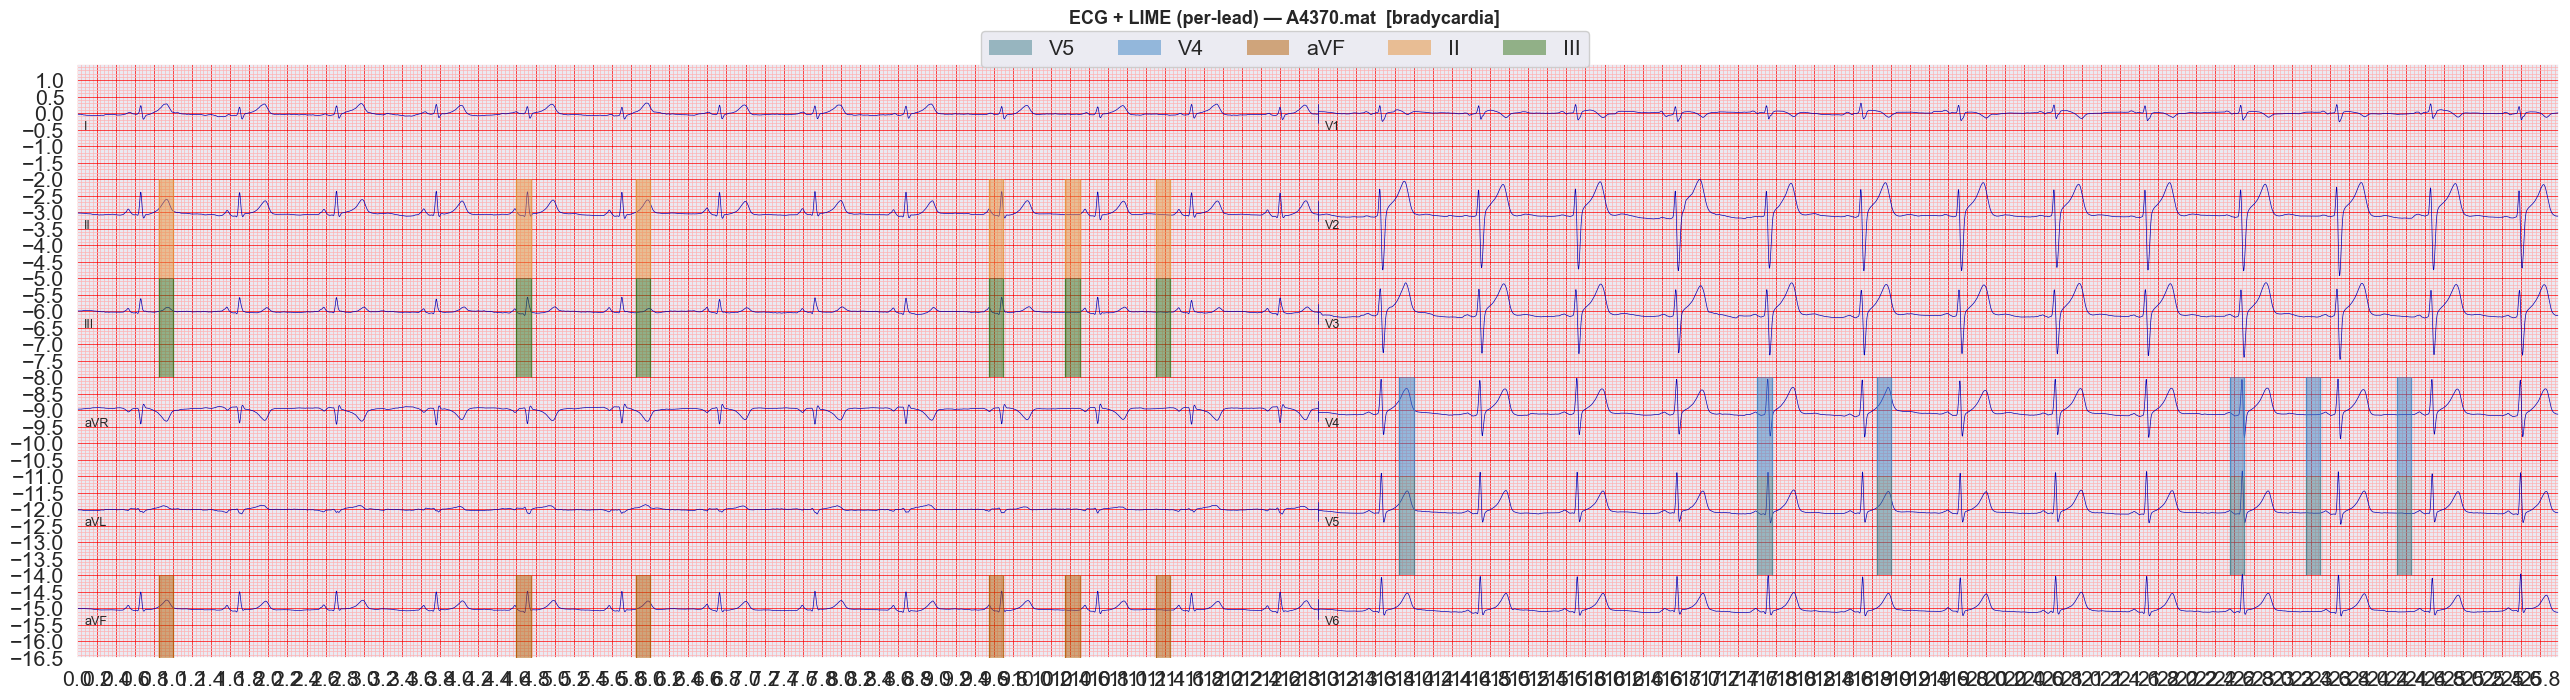

[DEBUG] inferred columns: 2, width≈13.000, centers=[0.07, 13.07]
[DEBUG] axis xlim=(0.0, 26.0), ylim=(-16.5, 1.5)


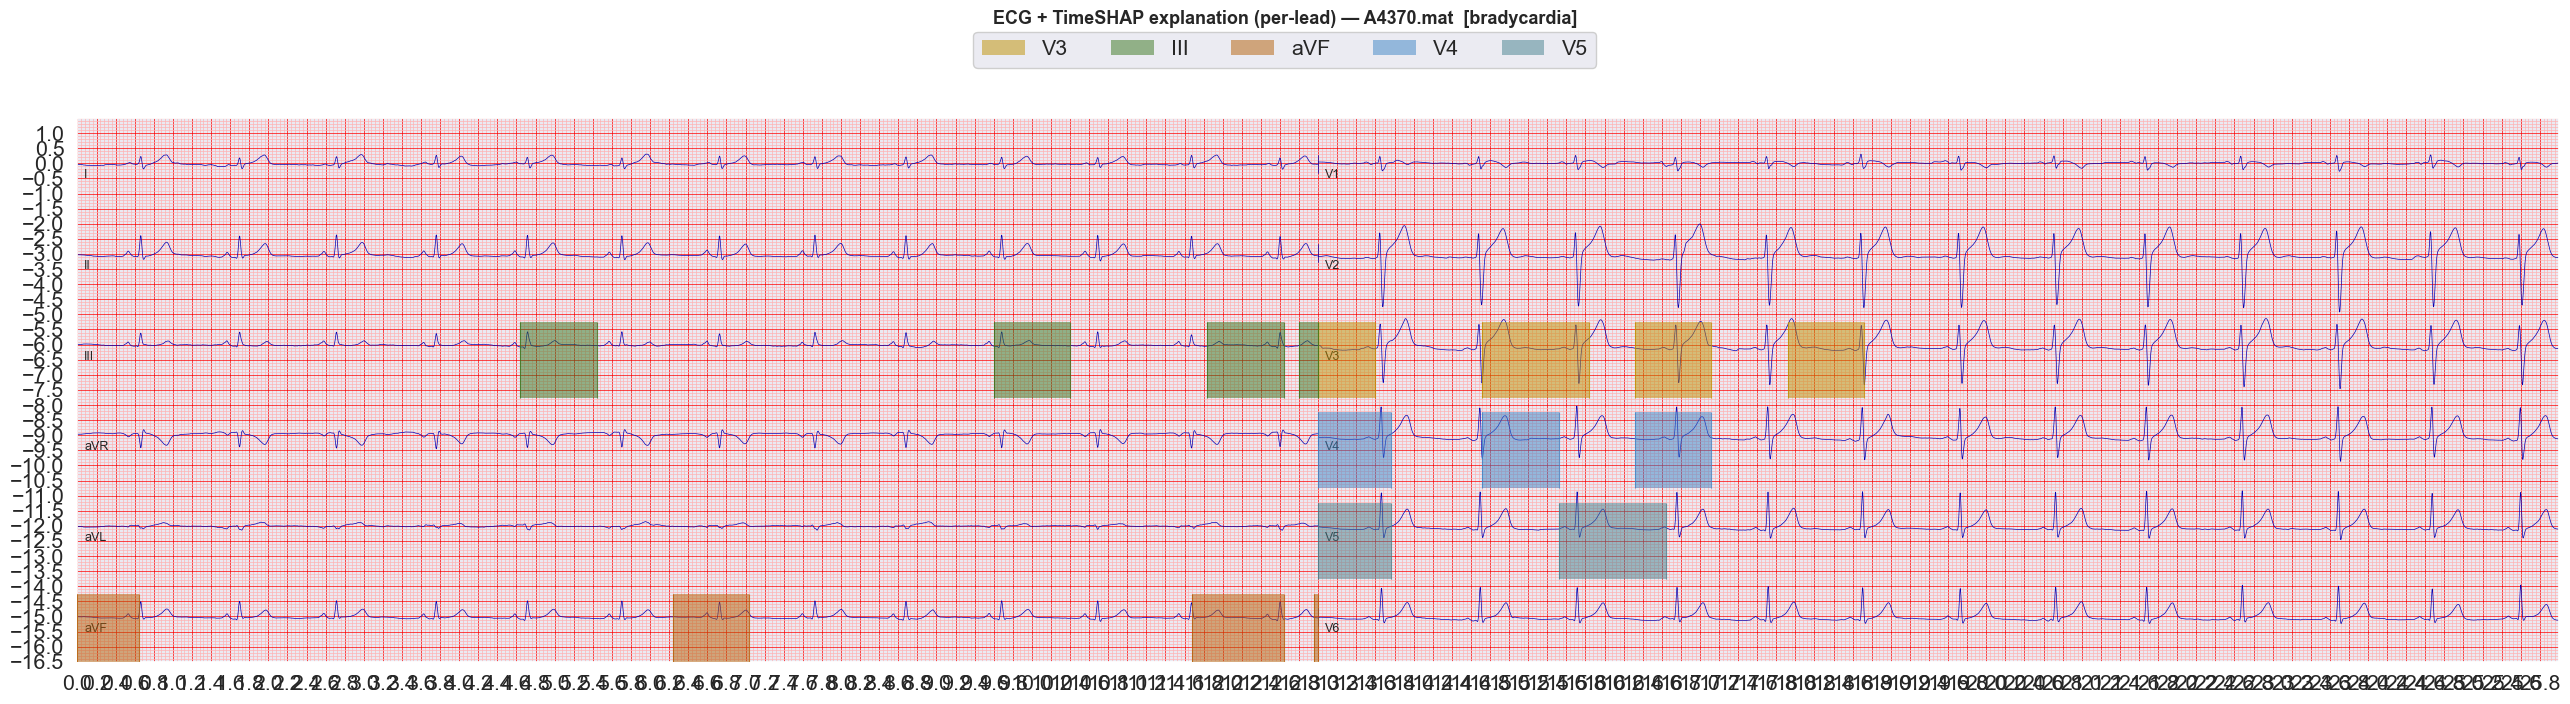

[DEBUG] xlim=(0.0, 26.0)  left_dom=(0.0, 13.0)  right_dom=(13.0, 26.0)
[DEBUG] I band=(1.0, -2.0)
[DEBUG] II band=(-2.0, -5.0)
[DEBUG] III band=(-5.0, -8.0)
[DEBUG] V1 band=(1.0, -2.0)
[DEBUG] V2 band=(-2.0, -5.0)
[DEBUG] V3 band=(-5.0, -8.0)


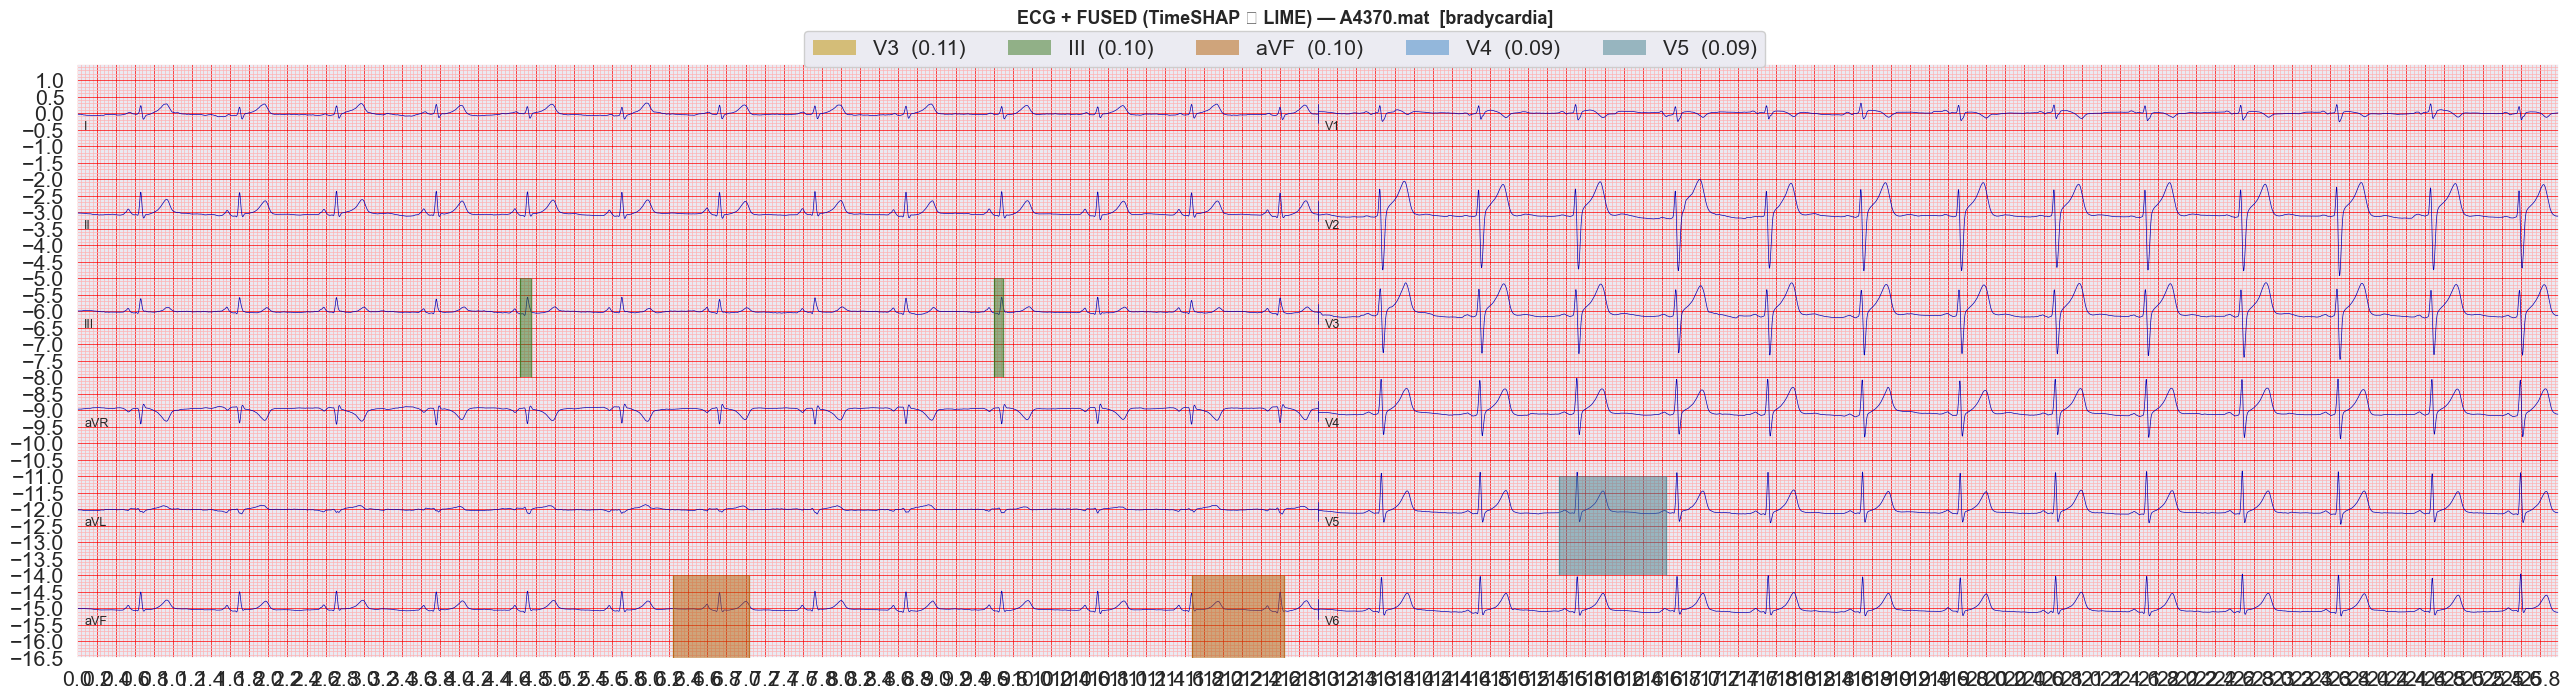

In [337]:
CSV_PATH = CSV_CACHE
ROW = 7822

lime_payload = run_lime_only_top5(
    CSV_PATH, ROW,
    page_seconds=20.0,   # 20s page (two columns)
    group=25,
    n_events=250, n_feat_masks=256, n_event_masks=256,
    topk_leads=5, topk_events_per_lead=6,
    widen_bins=1, merge_gap_bins=1,
    seed=42
)

ts_payload = run_timeshap_perlead_top5(
    CSV_PATH, ROW,
    page_seconds=20.0,       # or 30.0; plotter will infer domains from x-limits
    group=40,
    nsamples_event=256,
    baseline_mode="mean",
    fallback_zero=True,
    topk_leads=5,
    topk_events_per_lead=8,
    halfwidth_bins=2,
    min_span_sec=0.06,
    model_input_len=5000     # ResNet expects 5000x12
)

# Fuse (precise “consensus”; try alpha between 0.4–0.6):
fused_payload = fuse_lime_timeshap(
    lime_payload, ts_payload,
    alpha=0.5,
    span_mode="consensus",     # or "union" if prefer completeness
    top_k=5,
    topk_spans_per_lead=6,
    merge_gap=0.10,
    min_intersection=0.05
)

print(full_explanation(lime_payload, 
                        ts_payload, 
                        fused_payload, 
                        max_spans_per_lead=6))

plot_lime_top5(lime_payload, alpha_fill=0.5, debug=True)
plot_timeshap_top5(ts_payload, alpha_fill=0.5, debug=True)
plot_fused_top5(fused_payload, alpha_fill=0.5, debug=True)

# PRETRAIN THE MODEL

# TBC Add from here

If can plug into an LLM, and make the summary more human-readable.

timeshap pruning

Explainability Evaluation - example: consistency (Attribution consistency, attribution accuracy)

Find the place where the problematic bit is logged on the ecg